# Visualisierung der Parameter Sweep Ergebnisse

Analyse der Muskel-Prestretch und Kontraktion Simulationen aus `all_results_summary.csv`

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Seaborn-Stil für schönere Plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

## 1. Daten laden

In [4]:
# Pfad zur CSV-Datei
data_dir = Path('parameter_sweep_DA_20260227_194745')
csv_file = data_dir / 'all_results_summary.csv'

# Daten laden
df = pd.read_csv(csv_file)

print(f"Anzahl Simulationen: {len(df)}")
print(f"\nSpalten: {list(df.columns)}")
print(f"\nErste Zeilen:")
df.head()

Anzahl Simulationen: 3840

Spalten: ['Force_Target_N', 'Force_Actual_N', 'Stress_N_per_cm2', 'Aspect_Ratio_b_a', 'muscle_b_cm', 'muscle_a_cm', 'Volume_cm3', 'Am', 'Rho', 'Initial_Length_cm', 'Prestretch_Final_Length_cm', 'Prestretch_Elongation_cm', 'Prestretch_Strain', 'Max_Length_cm', 'Min_Length_cm', 'ROM_cm', 'Contraction_Strain', 'Completed_Date']

Erste Zeilen:


,Force_Target_N,Force_Actual_N,Stress_N_per_cm2,Aspect_Ratio_b_a,muscle_b_cm,muscle_a_cm,Volume_cm3,Am,Rho,Initial_Length_cm,Prestretch_Final_Length_cm,Prestretch_Elongation_cm,Prestretch_Strain,Max_Length_cm,Min_Length_cm,ROM_cm,Contraction_Strain,Completed_Date
0,3,3.874861,0.249296,6.88,27.124317,3.942488,421.6,450,10.534,27.124317,27.769125,0.644808,0.023772,27.769125,25.077824,2.691300,0.099220,Fr 27. Feb 20:43:10 CET 2026
1,3,3.874861,0.249296,6.88,27.124317,3.942488,421.6,450,10.493,27.124317,27.769125,0.644808,0.023772,27.769125,25.078110,2.691015,0.099210,Fr 27. Feb 20:43:11 CET 2026
2,6,7.749723,0.498592,6.88,27.124317,3.942488,421.6,450,10.534,27.124317,28.477810,1.353493,0.049899,28.477810,25.538082,2.939728,0.108379,Fr 27. Feb 20:43:13 CET 2026
3,0,0.000000,0.000000,6.88,27.124317,3.942488,421.6,450,10.493,27.124317,27.124317,0.000000,0.000000,27.124317,24.646892,2.477426,0.091335,Fr 27. Feb 20:43:13 CET 2026
4,6,7.749723,0.498592,6.88,27.124317,3.942488,421.6,450,10.493,27.124317,28.477810,1.353493,0.049899,28.477810,25.538279,2.939531,0.108372,Fr 27. Feb 20:43:13 CET 2026


In [5]:
# Datenübersicht
print("Datenstatistik:")
print(df.describe())

print("\n" + "="*80)
print("Parameter-Ranges:")
print("="*80)
print(f"Force_Target_N: {sorted(df['Force_Target_N'].unique())}")
print(f"Aspect_Ratio_b_a: {sorted(df['Aspect_Ratio_b_a'].unique())}")
print(f"Volume_cm3: {sorted(df['Volume_cm3'].unique())}")
print(f"Am: {sorted(df['Am'].unique())}")
print(f"Rho: {sorted(df['Rho'].unique())}")

Datenstatistik:
       Force_Target_N  Force_Actual_N  Stress_N_per_cm2  Aspect_Ratio_b_a  \
count     3840.000000     3840.000000       3840.000000       3840.000000   
mean        22.500000       31.291965          1.869721          8.490000   
std         13.831118       20.281070          1.149348          1.200187   
min          0.000000        0.000000          0.000000          6.880000   
25%         11.250000       14.225573          0.934860          7.684975   
50%         22.500000       30.366212          1.869721          8.490000   
75%         33.750000       46.613882          2.804581          9.295025   
max         45.000000       84.421168          3.739441         10.100000   

       muscle_b_cm  muscle_a_cm   Volume_cm3           Am          Rho  \
count  3840.000000  3840.000000  3840.000000  3840.000000  3840.000000   
mean     34.366540     4.075373   576.040000   500.000000    10.554500   
std       4.122928     0.357122   124.743668    40.830146     0.0458

## 2. Prestretch Analyse

/var/folders/qg/82ll9gvd1pd4329hnkdpf8ch0000gn/T/ipykernel_67259/1325920087.py:49: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/qg/82ll9gvd1pd4329hnkdpf8ch0000gn/T/ipykernel_67259/1325920087.py:50: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  plt.savefig(data_dir / 'prestretch_analysis.png', dpi=300, bbox_inches='tight')
/Users/canis/Library/Python/3.11/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


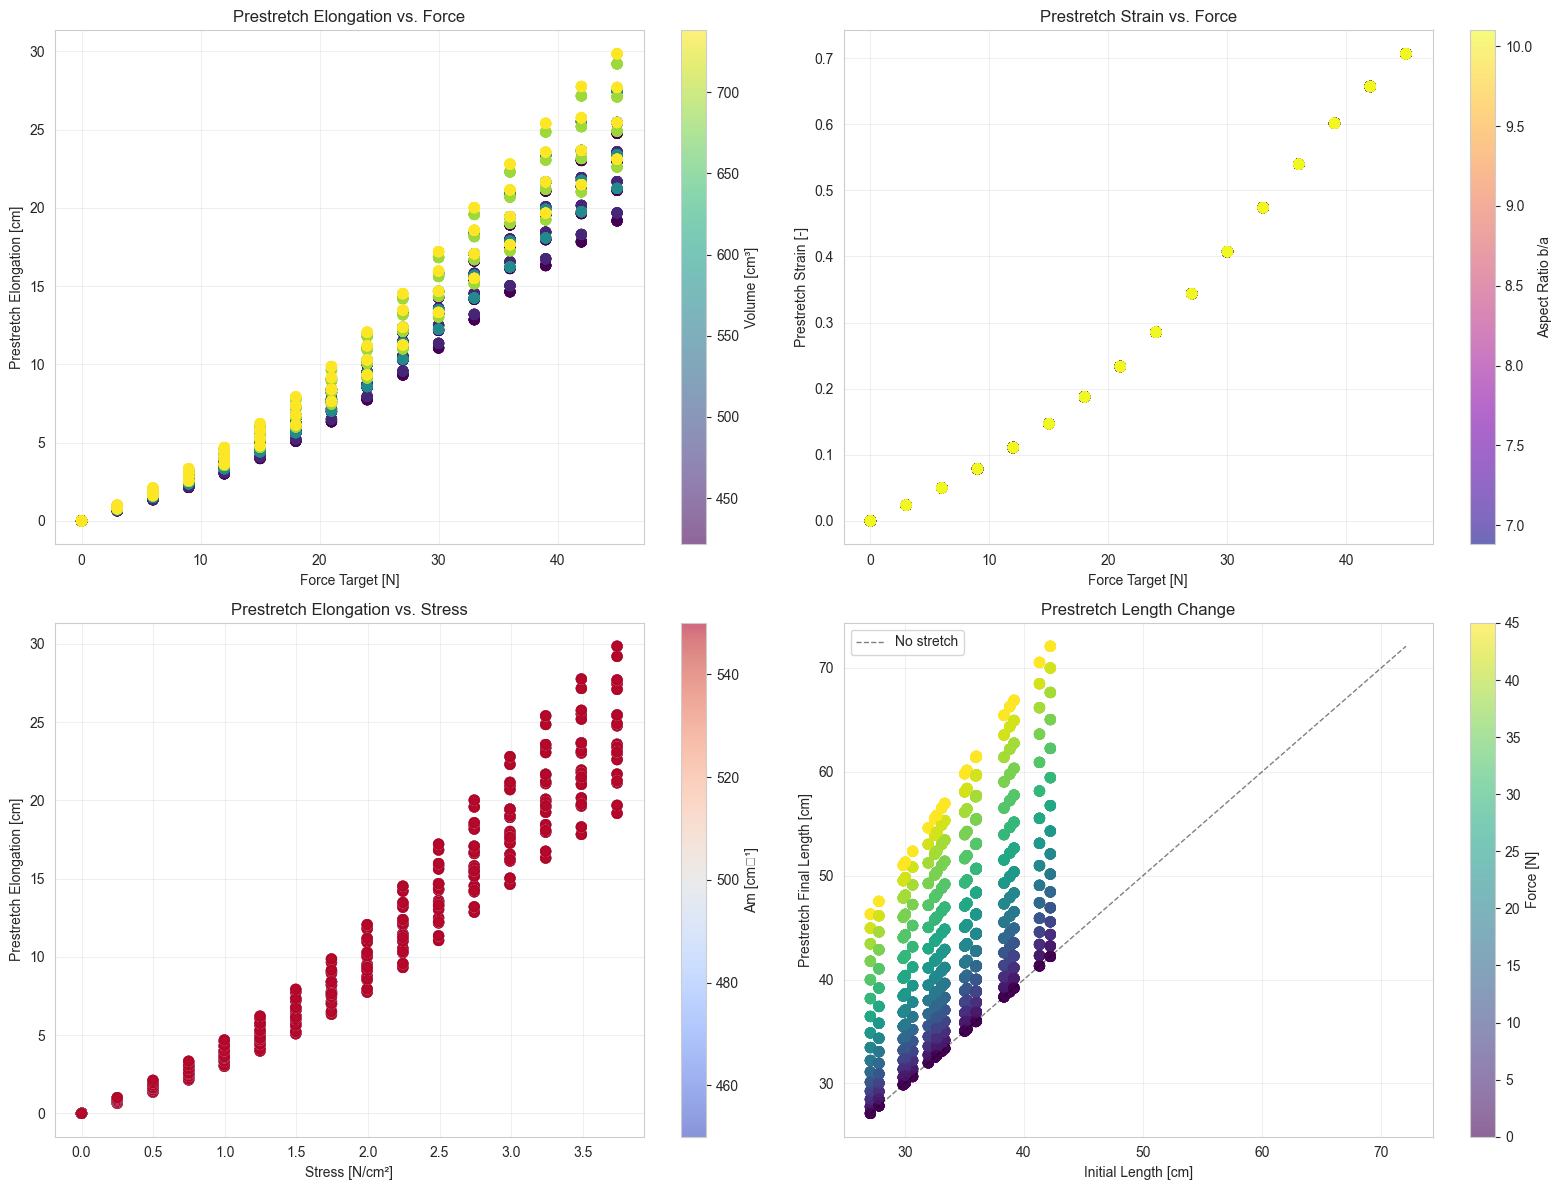

In [6]:
# Prestretch vs Force für verschiedene Parameter
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 2.1: Prestretch Elongation vs Force (alle Daten)
ax = axes[0, 0]
scatter = ax.scatter(df['Force_Target_N'], df['Prestretch_Elongation_cm'], 
                     c=df['Volume_cm3'], s=50, alpha=0.6, cmap='viridis')
ax.set_xlabel('Force Target [N]')
ax.set_ylabel('Prestretch Elongation [cm]')
ax.set_title('Prestretch Elongation vs. Force')
ax.grid(True, alpha=0.3)
plt.colorbar(scatter, ax=ax, label='Volume [cm³]')

# 2.2: Prestretch Strain vs Force
ax = axes[0, 1]
scatter = ax.scatter(df['Force_Target_N'], df['Prestretch_Strain'], 
                     c=df['Aspect_Ratio_b_a'], s=50, alpha=0.6, cmap='plasma')
ax.set_xlabel('Force Target [N]')
ax.set_ylabel('Prestretch Strain [-]')
ax.set_title('Prestretch Strain vs. Force')
ax.grid(True, alpha=0.3)
plt.colorbar(scatter, ax=ax, label='Aspect Ratio b/a')

# 2.3: Prestretch Elongation vs Stress
ax = axes[1, 0]
scatter = ax.scatter(df['Stress_N_per_cm2'], df['Prestretch_Elongation_cm'], 
                     c=df['Am'], s=50, alpha=0.6, cmap='coolwarm')
ax.set_xlabel('Stress [N/cm²]')
ax.set_ylabel('Prestretch Elongation [cm]')
ax.set_title('Prestretch Elongation vs. Stress')
ax.grid(True, alpha=0.3)
plt.colorbar(scatter, ax=ax, label='Am [cm⁻¹]')

# 2.4: Prestretch Final Length vs Initial Length
ax = axes[1, 1]
scatter = ax.scatter(df['Initial_Length_cm'], df['Prestretch_Final_Length_cm'], 
                     c=df['Force_Target_N'], s=50, alpha=0.6, cmap='viridis')
# Diagonale einzeichnen
lims = [df[['Initial_Length_cm', 'Prestretch_Final_Length_cm']].min().min(),
        df[['Initial_Length_cm', 'Prestretch_Final_Length_cm']].max().max()]
ax.plot(lims, lims, 'k--', alpha=0.5, linewidth=1, label='No stretch')
ax.set_xlabel('Initial Length [cm]')
ax.set_ylabel('Prestretch Final Length [cm]')
ax.set_title('Prestretch Length Change')
ax.grid(True, alpha=0.3)
ax.legend()
plt.colorbar(scatter, ax=ax, label='Force [N]')

plt.tight_layout()
plt.savefig(data_dir / 'prestretch_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

## 2.1. **KRITISCHE ANALYSE**: Force-Skalierung und Stress-Konsistenz

⚠️ Überprüfung ob die Force-Skalierung korrekt funktioniert und ob der Stress über alle Geometrien hinweg konstant bleibt.

In [7]:
# Berechne Surface Area aus den Daten
df['Surface_Area_calc'] = df['muscle_a_cm'] ** 2

# Reference Area (aus bash script)
REFERENCE_AREA = 12.033883  # cm²

# Prüfe die Force-Skalierung
df['Force_Scaling_Factor'] = df['Force_Actual_N'] / df['Force_Target_N']
df['Expected_Scaling_Factor'] = df['Surface_Area_calc'] / REFERENCE_AREA

print("Force-Skalierung Überprüfung:")
print("=" * 80)
print(f"\nReference Area: {REFERENCE_AREA} cm²")
print(f"\nSurface Area Range: {df['Surface_Area_calc'].min():.4f} - {df['Surface_Area_calc'].max():.4f} cm²")
print(f"Expected Scaling Range: {df['Expected_Scaling_Factor'].min():.4f} - {df['Expected_Scaling_Factor'].max():.4f}")
print(f"Actual Scaling Range: {df['Force_Scaling_Factor'].min():.4f} - {df['Force_Scaling_Factor'].max():.4f}")

# Prüfe ob Stress konstant ist für gleiche Force_Target
print("\n" + "=" * 80)
print("Stress-Konsistenz für gleiche Force_Target:")
print("=" * 80)
for force_target in sorted(df[df['Force_Target_N'] > 0]['Force_Target_N'].unique())[:3]:
    subset = df[df['Force_Target_N'] == force_target]
    stress_mean = subset['Stress_N_per_cm2'].mean()
    stress_std = subset['Stress_N_per_cm2'].std()
    print(f"Force_Target = {force_target:2.0f} N: Stress = {stress_mean:.6f} ± {stress_std:.6f} N/cm²")
    
# Berechne theoretischen Stress
df['Stress_Theory'] = df['Force_Target_N'] / REFERENCE_AREA

print("\n" + "=" * 80)
print("Theoretischer vs. Tatsächlicher Stress:")
print("=" * 80)
comparison = df.groupby('Force_Target_N').agg({
    'Stress_Theory': 'first',
    'Stress_N_per_cm2': ['mean', 'std']
}).round(6)
print(comparison.head(10))

Force-Skalierung Überprüfung:

Reference Area: 12.033883 cm²

Surface Area Range: 12.0333 - 22.5759 cm²
Expected Scaling Range: 1.0000 - 1.8760
Actual Scaling Range: 1.0000 - 1.8760

Stress-Konsistenz für gleiche Force_Target:
Force_Target =  3 N: Stress = 0.249296 ± 0.000000 N/cm²
Force_Target =  6 N: Stress = 0.498592 ± 0.000000 N/cm²
Force_Target =  9 N: Stress = 0.747888 ± 0.000000 N/cm²

Theoretischer vs. Tatsächlicher Stress:
               Stress_Theory Stress_N_per_cm2     
                       first             mean  std
Force_Target_N                                    
0                   0.000000         0.000000  0.0
3                   0.249296         0.249296  0.0
6                   0.498592         0.498592  0.0
9                   0.747888         0.747888  0.0
12                  0.997184         0.997184  0.0
15                  1.246480         1.246480  0.0
18                  1.495777         1.495777  0.0
21                  1.745073         1.745073  0.0
24 

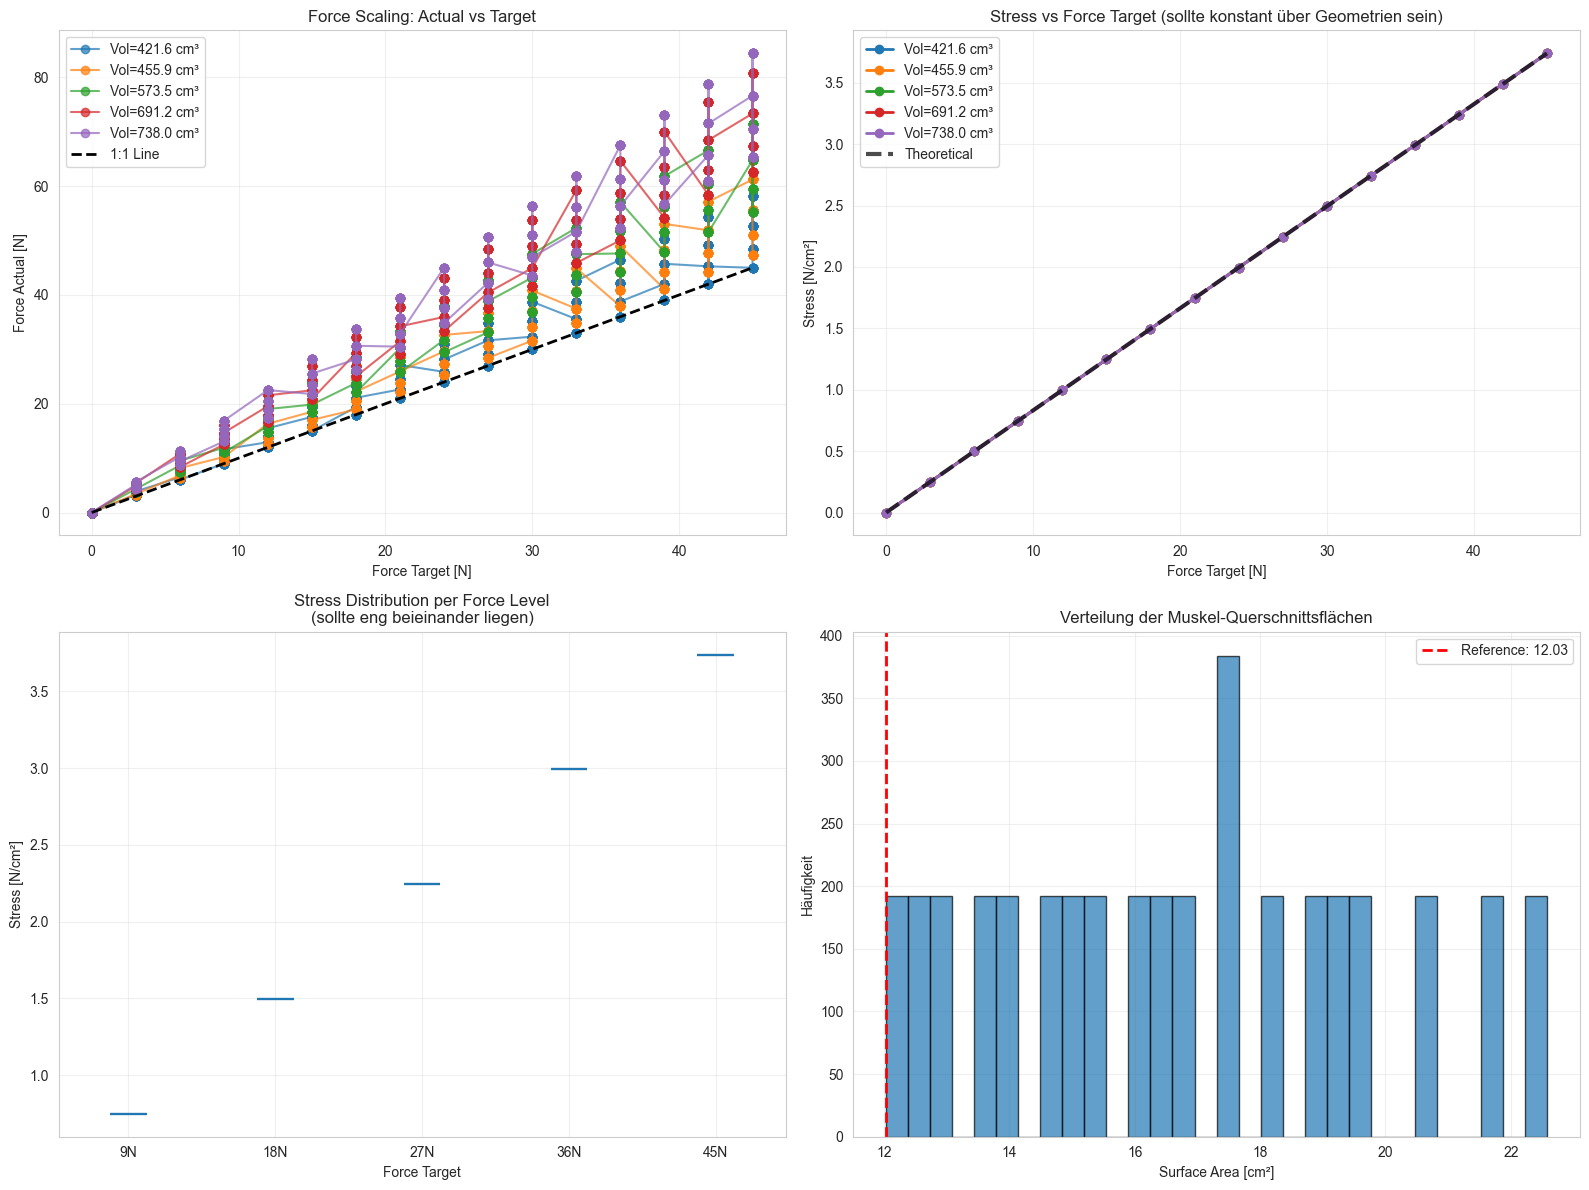

In [8]:
# Visualisierung der Force-Skalierung
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Force_Actual vs Force_Target - sollte LINEAR sein mit unterschiedlichen Steigungen
ax = axes[0, 0]
for vol in sorted(df['Volume_cm3'].unique()):
    subset = df[df['Volume_cm3'] == vol]
    subset_sorted = subset.sort_values('Force_Target_N')
    ax.plot(subset_sorted['Force_Target_N'], subset_sorted['Force_Actual_N'], 
            'o-', label=f'Vol={vol:.1f} cm³', alpha=0.7)
ax.plot([0, 45], [0, 45], 'k--', linewidth=2, label='1:1 Line')
ax.set_xlabel('Force Target [N]')
ax.set_ylabel('Force Actual [N]')
ax.set_title('Force Scaling: Actual vs Target')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. Stress vs Force_Target - sollte KONSTANT sein pro Force_Target
ax = axes[0, 1]
for vol in sorted(df['Volume_cm3'].unique()):
    subset = df[df['Volume_cm3'] == vol]
    subset_grouped = subset.groupby('Force_Target_N')[['Stress_N_per_cm2']].mean()
    ax.plot(subset_grouped.index, subset_grouped['Stress_N_per_cm2'], 
            'o-', label=f'Vol={vol:.1f} cm³', linewidth=2)
# Theoretischer Stress
theo_forces = np.linspace(0, 45, 10)
theo_stress = theo_forces / REFERENCE_AREA
ax.plot(theo_forces, theo_stress, 'k--', linewidth=3, label='Theoretical', alpha=0.7)
ax.set_xlabel('Force Target [N]')
ax.set_ylabel('Stress [N/cm²]')
ax.set_title('Stress vs Force Target (sollte konstant über Geometrien sein)')
ax.legend()
ax.grid(True, alpha=0.3)

# 3. Stress Distribution per Force Level
ax = axes[1, 0]
force_levels = [9, 18, 27, 36, 45]
positions = []
stress_values = []
labels = []
for i, force in enumerate(force_levels):
    subset = df[df['Force_Target_N'] == force]
    positions.extend([i] * len(subset))
    stress_values.extend(subset['Stress_N_per_cm2'].values)
    labels.append(f'{force}N')
    
ax.violinplot([df[df['Force_Target_N'] == f]['Stress_N_per_cm2'].values 
               for f in force_levels], 
              positions=range(len(force_levels)), 
              showmeans=True, showmedians=True)
ax.set_xticks(range(len(force_levels)))
ax.set_xticklabels(labels)
ax.set_xlabel('Force Target')
ax.set_ylabel('Stress [N/cm²]')
ax.set_title('Stress Distribution per Force Level\n(sollte eng beieinander liegen)')
ax.grid(True, alpha=0.3)

# 4. Surface Area Distribution
ax = axes[1, 1]
ax.hist(df['Surface_Area_calc'], bins=30, alpha=0.7, edgecolor='black')
ax.axvline(REFERENCE_AREA, color='red', linestyle='--', linewidth=2, label=f'Reference: {REFERENCE_AREA:.2f}')
ax.set_xlabel('Surface Area [cm²]')
ax.set_ylabel('Häufigkeit')
ax.set_title('Verteilung der Muskel-Querschnittsflächen')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(data_dir / 'force_scaling_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

## 2.2. **PROBLEM-ANALYSE**: ROM vs Force Beziehung

🔍 Das Hauptproblem: ROM sollte mit Force steigen (oder parabolisch sein), aber zeigt stattdessen ein Minimum bei mittleren Forces.

/var/folders/qg/82ll9gvd1pd4329hnkdpf8ch0000gn/T/ipykernel_67259/4281527416.py:81: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/qg/82ll9gvd1pd4329hnkdpf8ch0000gn/T/ipykernel_67259/4281527416.py:81: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/qg/82ll9gvd1pd4329hnkdpf8ch0000gn/T/ipykernel_67259/4281527416.py:82: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  plt.savefig(data_dir / 'rom_problem_analysis.png', dpi=300, bbox_inches='tight')
/var/folders/qg/82ll9gvd1pd4329hnkdpf8ch0000gn/T/ipykernel_67259/4281527416.py:82: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  plt.savefig(data_dir / 'rom_problem_analysis.png', dpi=300, bbox_inches='tight')
/Users/canis/Library/Python/3.11/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Ar

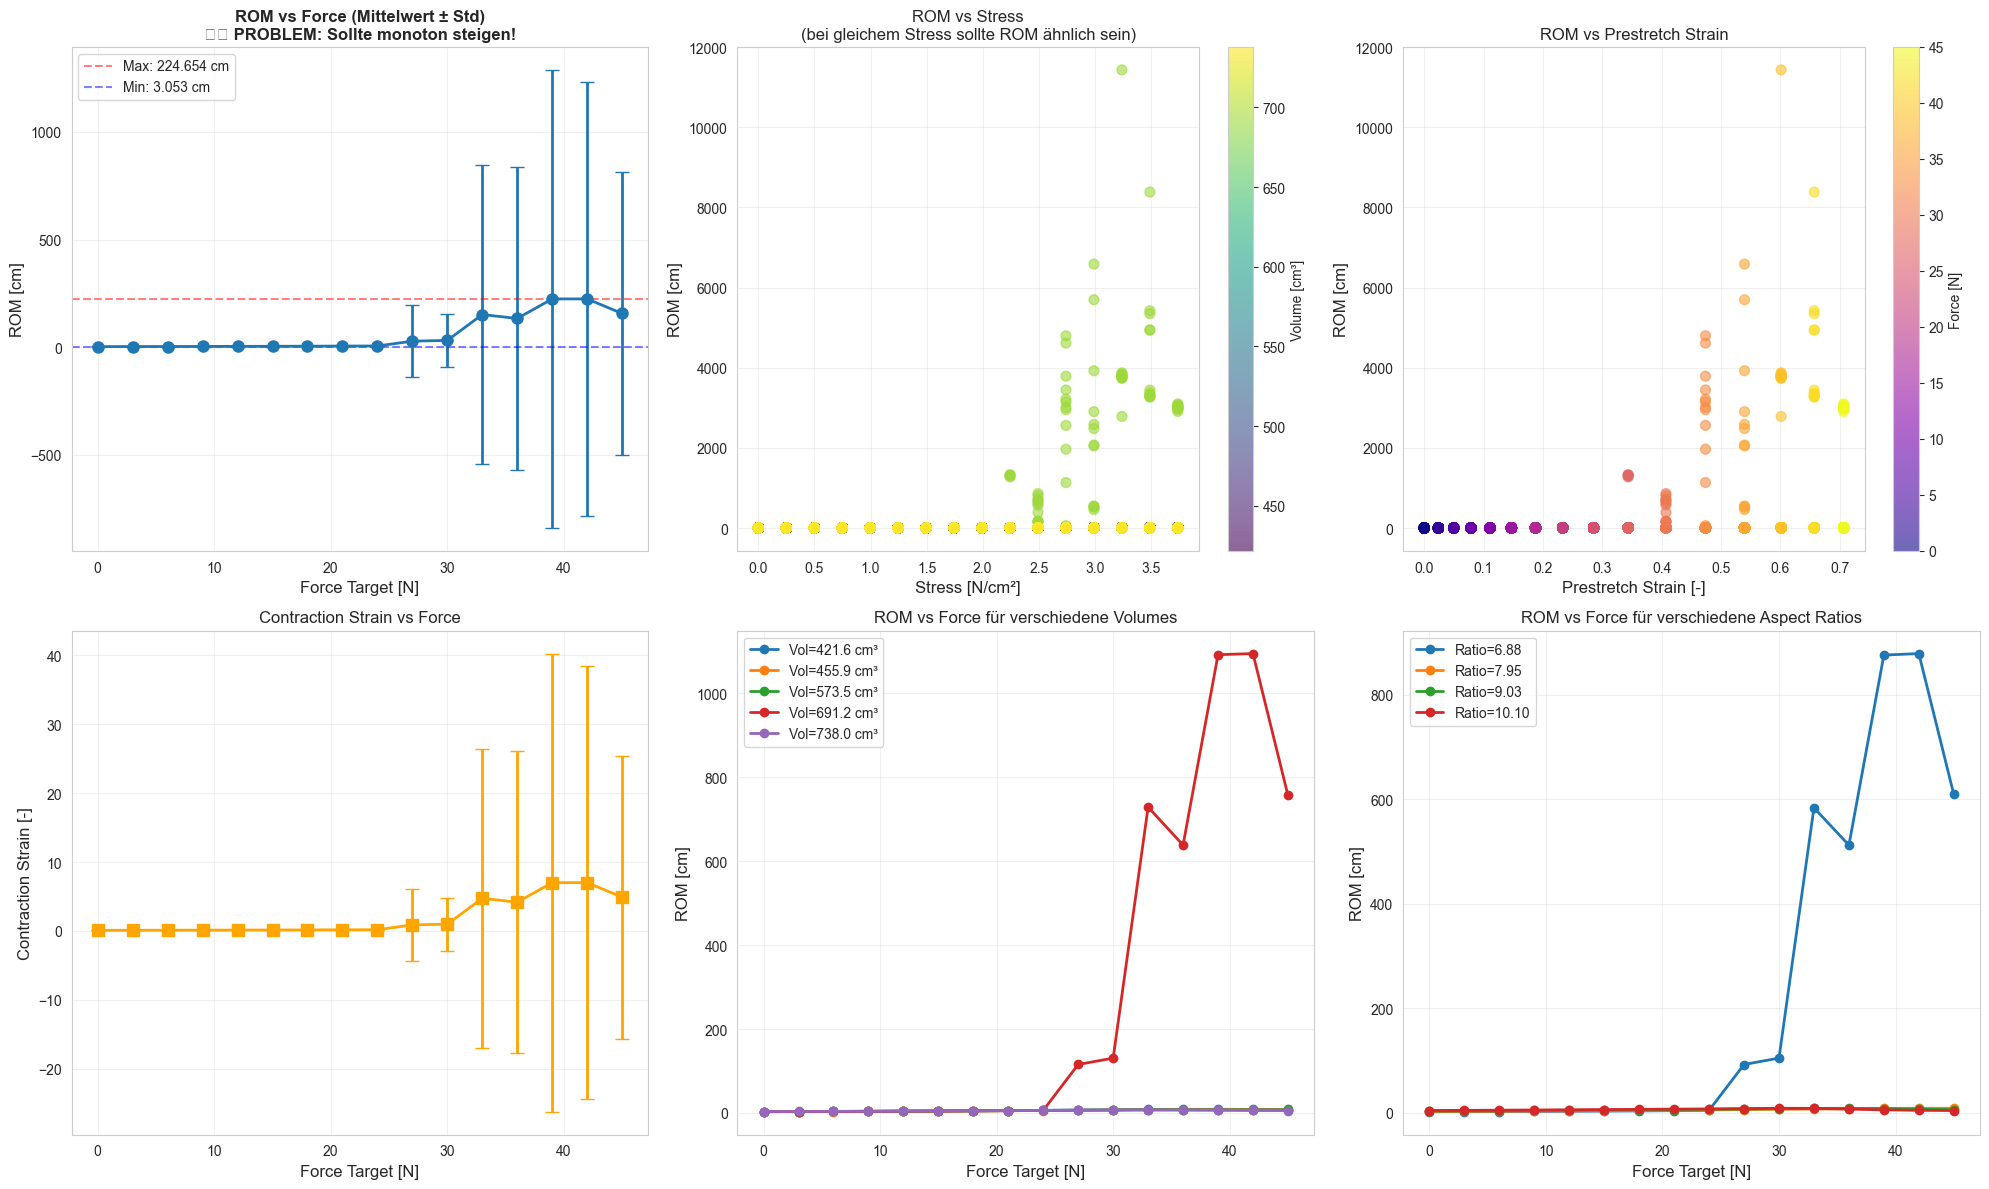

ROM Statistik nach Force:
                    ROM_cm                   
                      mean          std count
Force_Target_N                               
0                 3.052772     0.918759   240
3                 3.283642     0.959866   240
6                 3.544683     1.004518   240
9                 3.842731     1.059651   240
12                4.187494     1.095688   240
15                4.570453     1.121091   240
18                4.993289     1.167946   240
21                5.465090     1.147494   240
24                6.005209     1.083969   240
27               28.320972   167.016179   240
30               31.851814   122.750820   240
33              151.858326   693.097961   240
36              133.766565   702.072506   240
39              224.380119  1063.806915   240
42              224.654096  1007.316594   240
45              156.950169   656.485462   240


In [9]:
# ROM vs Force - Detailanalyse
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# 1. ROM vs Force_Target (Mittelwerte mit Fehlerbalken)
ax = axes[0, 0]
rom_by_force = df.groupby('Force_Target_N').agg({
    'ROM_cm': ['mean', 'std', 'count']
})
forces = rom_by_force.index
rom_mean = rom_by_force['ROM_cm']['mean']
rom_std = rom_by_force['ROM_cm']['std']
ax.errorbar(forces, rom_mean, yerr=rom_std, fmt='o-', linewidth=2, markersize=8, capsize=5)
ax.set_xlabel('Force Target [N]', fontsize=12)
ax.set_ylabel('ROM [cm]', fontsize=12)
ax.set_title('ROM vs Force (Mittelwert ± Std)\n⚠️ PROBLEM: Sollte monoton steigen!', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.axhline(y=rom_mean.max(), color='red', linestyle='--', alpha=0.5, label=f'Max: {rom_mean.max():.3f} cm')
ax.axhline(y=rom_mean.min(), color='blue', linestyle='--', alpha=0.5, label=f'Min: {rom_mean.min():.3f} cm')
ax.legend()

# 2. ROM vs Stress (sollte konsistenter sein)
ax = axes[0, 1]
scatter = ax.scatter(df['Stress_N_per_cm2'], df['ROM_cm'], 
                     c=df['Volume_cm3'], s=50, alpha=0.6, cmap='viridis')
ax.set_xlabel('Stress [N/cm²]', fontsize=12)
ax.set_ylabel('ROM [cm]', fontsize=12)
ax.set_title('ROM vs Stress\n(bei gleichem Stress sollte ROM ähnlich sein)', fontsize=12)
ax.grid(True, alpha=0.3)
plt.colorbar(scatter, ax=ax, label='Volume [cm³]')

# 3. ROM vs Prestretch Strain
ax = axes[0, 2]
scatter = ax.scatter(df['Prestretch_Strain'], df['ROM_cm'], 
                     c=df['Force_Target_N'], s=50, alpha=0.6, cmap='plasma')
ax.set_xlabel('Prestretch Strain [-]', fontsize=12)
ax.set_ylabel('ROM [cm]', fontsize=12)
ax.set_title('ROM vs Prestretch Strain', fontsize=12)
ax.grid(True, alpha=0.3)
plt.colorbar(scatter, ax=ax, label='Force [N]')

# 4. Contraction Strain vs Force
ax = axes[1, 0]
strain_by_force = df.groupby('Force_Target_N').agg({
    'Contraction_Strain': ['mean', 'std']
})
forces = strain_by_force.index
strain_mean = strain_by_force['Contraction_Strain']['mean']
strain_std = strain_by_force['Contraction_Strain']['std']
ax.errorbar(forces, strain_mean, yerr=strain_std, fmt='s-', linewidth=2, markersize=8, capsize=5, color='orange')
ax.set_xlabel('Force Target [N]', fontsize=12)
ax.set_ylabel('Contraction Strain [-]', fontsize=12)
ax.set_title('Contraction Strain vs Force', fontsize=12)
ax.grid(True, alpha=0.3)

# 5. ROM für verschiedene Volumes
ax = axes[1, 1]
for vol in sorted(df['Volume_cm3'].unique()):
    subset = df[df['Volume_cm3'] == vol]
    subset_grouped = subset.groupby('Force_Target_N')[['ROM_cm']].mean()
    ax.plot(subset_grouped.index, subset_grouped['ROM_cm'], 
            'o-', label=f'Vol={vol:.1f} cm³', linewidth=2, markersize=6)
ax.set_xlabel('Force Target [N]', fontsize=12)
ax.set_ylabel('ROM [cm]', fontsize=12)
ax.set_title('ROM vs Force für verschiedene Volumes', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

# 6. ROM für verschiedene Aspect Ratios
ax = axes[1, 2]
for ratio in sorted(df['Aspect_Ratio_b_a'].unique()):
    subset = df[df['Aspect_Ratio_b_a'] == ratio]
    subset_grouped = subset.groupby('Force_Target_N')[['ROM_cm']].mean()
    ax.plot(subset_grouped.index, subset_grouped['ROM_cm'], 
            'o-', label=f'Ratio={ratio:.2f}', linewidth=2, markersize=6)
ax.set_xlabel('Force Target [N]', fontsize=12)
ax.set_ylabel('ROM [cm]', fontsize=12)
ax.set_title('ROM vs Force für verschiedene Aspect Ratios', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(data_dir / 'rom_problem_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# Statistik ausgeben
print("="*80)
print("ROM Statistik nach Force:")
print("="*80)
print(rom_by_force.round(6))

## 2.3. **GEOMETRIE-ÜBERPRÜFUNG**: Volume, Aspect Ratio, Dimensions

Überprüfung der Geometrie-Berechnungen: Volume = a² × b, Aspect Ratio = b/a

Geometrie-Überprüfung:
Volume Error (max): 0.0026262289 cm³
Aspect Ratio Error (max): 0.0000002528
Initial Length Error (max): 0.0000000000 cm

Geometrie-Parameter pro Kombination:
                             muscle_a_cm  muscle_b_cm  Surface_Area_calc  \
Volume_cm3 Aspect_Ratio_b_a                                                
421.6      6.8800               3.942488    27.124317          15.543212   
           7.9533               3.756508    29.876635          14.111352   
           9.0267               3.601282    32.507692          12.969232   
           10.1000              3.468908    35.035970          12.033323   
455.9      6.8800               4.046628    27.840800          16.375198   
           7.9533               3.855736    30.665825          14.866700   
           9.0267               3.696409    33.366375          13.663439   
           10.1000              3.560539    35.961443          12.677438   
573.5      6.8800               4.368322    30.054055      

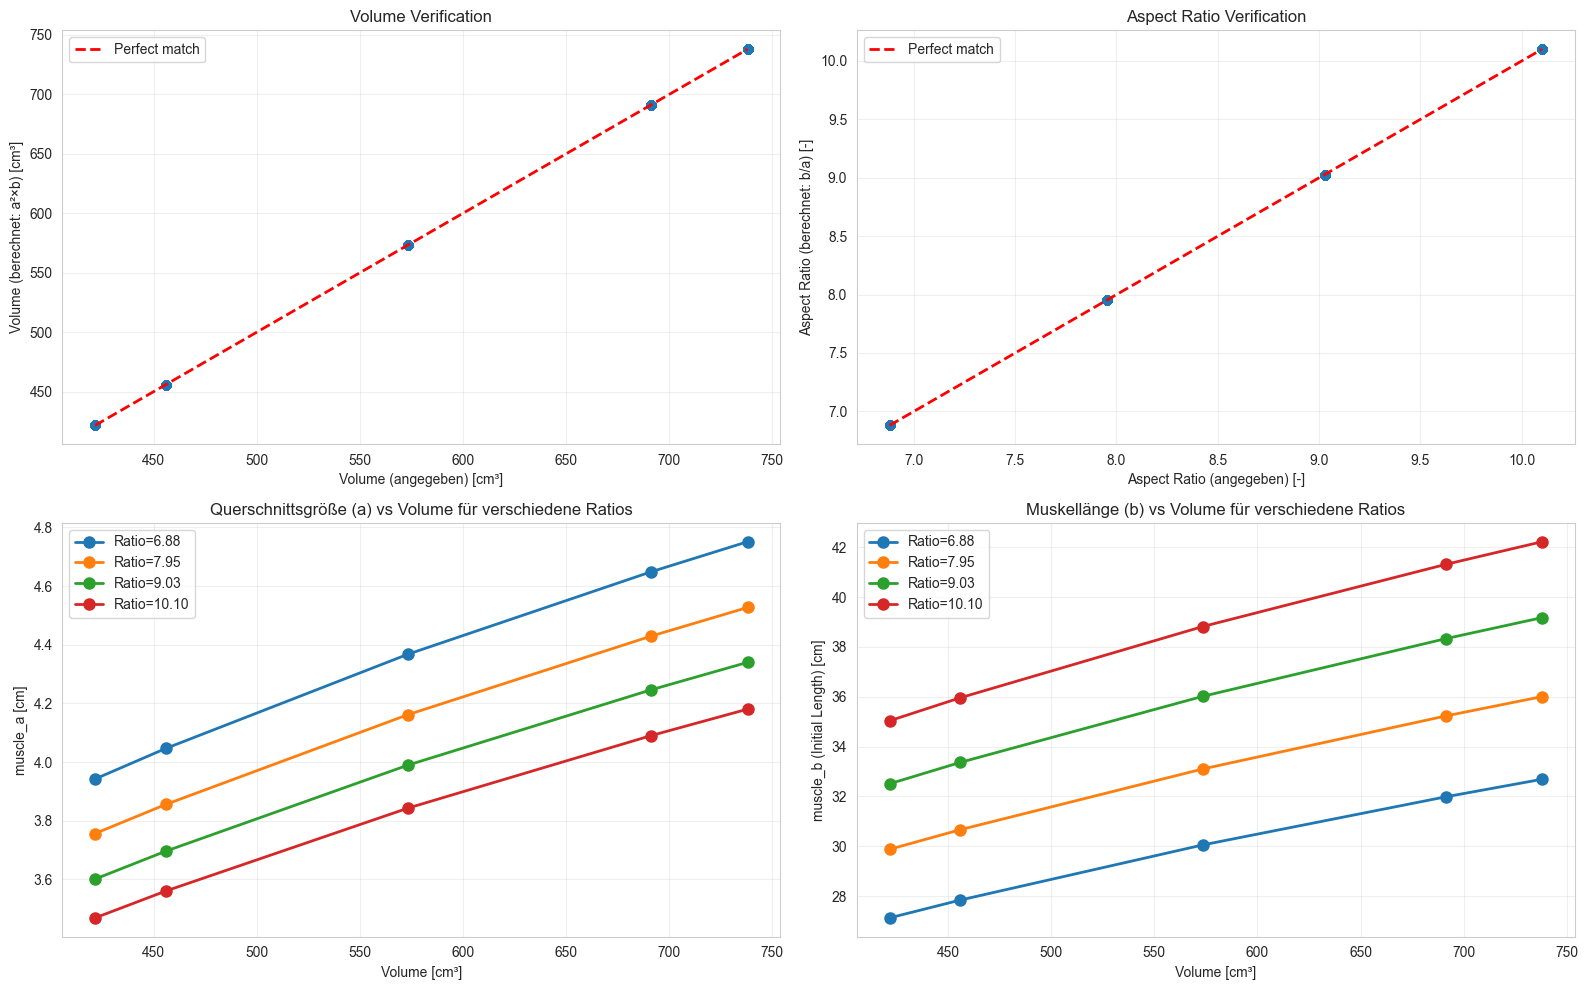

In [10]:
# Überprüfe Geometrie-Berechnungen
df['Volume_check'] = df['muscle_a_cm']**2 * df['muscle_b_cm']
df['Aspect_Ratio_check'] = df['muscle_b_cm'] / df['muscle_a_cm']
df['Initial_Length_check'] = df['muscle_b_cm']

# Fehler berechnen
df['Volume_error'] = np.abs(df['Volume_cm3'] - df['Volume_check'])
df['Ratio_error'] = np.abs(df['Aspect_Ratio_b_a'] - df['Aspect_Ratio_check'])
df['Length_error'] = np.abs(df['Initial_Length_cm'] - df['Initial_Length_check'])

print("Geometrie-Überprüfung:")
print("="*80)
print(f"Volume Error (max): {df['Volume_error'].max():.10f} cm³")
print(f"Aspect Ratio Error (max): {df['Ratio_error'].max():.10f}")
print(f"Initial Length Error (max): {df['Length_error'].max():.10f} cm")

if df['Volume_error'].max() > 0.01:
    print("\n⚠️ WARNING: Große Volume-Fehler gefunden!")
if df['Ratio_error'].max() > 0.01:
    print("⚠️ WARNING: Große Aspect Ratio-Fehler gefunden!")
if df['Length_error'].max() > 0.01:
    print("⚠️ WARNING: Große Initial Length-Fehler gefunden!")

# Gruppiere nach Volume und Ratio
print("\n" + "="*80)
print("Geometrie-Parameter pro Kombination:")
print("="*80)
geo_summary = df.groupby(['Volume_cm3', 'Aspect_Ratio_b_a']).agg({
    'muscle_a_cm': 'first',
    'muscle_b_cm': 'first',
    'Surface_Area_calc': 'first',
    'Initial_Length_cm': 'first'
}).round(6)
print(geo_summary)

# Visualisierung
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Volume vs (a² × b)
ax = axes[0, 0]
ax.scatter(df['Volume_cm3'], df['Volume_check'], alpha=0.6)
lim = [df[['Volume_cm3', 'Volume_check']].min().min(), 
       df[['Volume_cm3', 'Volume_check']].max().max()]
ax.plot(lim, lim, 'r--', linewidth=2, label='Perfect match')
ax.set_xlabel('Volume (angegeben) [cm³]')
ax.set_ylabel('Volume (berechnet: a²×b) [cm³]')
ax.set_title('Volume Verification')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. Aspect Ratio vs (b/a)
ax = axes[0, 1]
ax.scatter(df['Aspect_Ratio_b_a'], df['Aspect_Ratio_check'], alpha=0.6)
lim = [df[['Aspect_Ratio_b_a', 'Aspect_Ratio_check']].min().min(), 
       df[['Aspect_Ratio_b_a', 'Aspect_Ratio_check']].max().max()]
ax.plot(lim, lim, 'r--', linewidth=2, label='Perfect match')
ax.set_xlabel('Aspect Ratio (angegeben) [-]')
ax.set_ylabel('Aspect Ratio (berechnet: b/a) [-]')
ax.set_title('Aspect Ratio Verification')
ax.legend()
ax.grid(True, alpha=0.3)

# 3. muscle_a vs Volume für verschiedene Ratios
ax = axes[1, 0]
for ratio in sorted(df['Aspect_Ratio_b_a'].unique()):
    subset = df[df['Aspect_Ratio_b_a'] == ratio]
    subset_unique = subset.drop_duplicates(subset=['Volume_cm3', 'Aspect_Ratio_b_a'])
    ax.plot(subset_unique['Volume_cm3'], subset_unique['muscle_a_cm'], 
            'o-', label=f'Ratio={ratio:.2f}', linewidth=2, markersize=8)
ax.set_xlabel('Volume [cm³]')
ax.set_ylabel('muscle_a [cm]')
ax.set_title('Querschnittsgröße (a) vs Volume für verschiedene Ratios')
ax.legend()
ax.grid(True, alpha=0.3)

# 4. muscle_b (Initial Length) vs Volume für verschiedene Ratios
ax = axes[1, 1]
for ratio in sorted(df['Aspect_Ratio_b_a'].unique()):
    subset = df[df['Aspect_Ratio_b_a'] == ratio]
    subset_unique = subset.drop_duplicates(subset=['Volume_cm3', 'Aspect_Ratio_b_a'])
    ax.plot(subset_unique['Volume_cm3'], subset_unique['muscle_b_cm'], 
            'o-', label=f'Ratio={ratio:.2f}', linewidth=2, markersize=8)
ax.set_xlabel('Volume [cm³]')
ax.set_ylabel('muscle_b (Initial Length) [cm]')
ax.set_title('Muskellänge (b) vs Volume für verschiedene Ratios')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(data_dir / 'geometry_verification.png', dpi=300, bbox_inches='tight')
plt.show()

## 2.4. **DIAGNOSE**: Mögliche Fehlerquellen

Zusammenfassung der möglichen Probleme basierend auf den Analysen oben.

In [11]:
print("="*80)
print("DIAGNOSE: Mögliche Fehlerquellen")
print("="*80)
print()

# Problem 1: Simulationszeit
print("1. ⚠️ SIMULATIONSZEIT ZU KURZ")
print("   - Aktuelle Daten zeigen nur 50ms Simulation (500 Zeitschritte @ 0.1ms)")
print("   - Eine vollständige Muskelzuckung benötigt 100-200ms")
print("   - ROM wird mitten in der Kontraktion gemessen → FALSCHE WERTE!")
print("   - LÖSUNG: ENDTIME_MS auf 200ms setzen (bereits in run_parameter_sweep_2702.sh gefixt)")
print()

# Problem 2: ROM Trend
rom_at_0 = df[df['Force_Target_N'] == 0]['ROM_cm'].mean()
rom_at_45 = df[df['Force_Target_N'] == 45]['ROM_cm'].mean()
rom_diff = rom_at_45 - rom_at_0
rom_change_percent = (rom_diff / rom_at_0) * 100

print(f"2. ⚠️ ROM VERHÄLTNIS")
print(f"   - ROM bei Force=0N:  {rom_at_0:.4f} cm")
print(f"   - ROM bei Force=45N: {rom_at_45:.4f} cm")
print(f"   - Differenz: {rom_diff:.4f} cm ({rom_change_percent:.1f}%)")
if rom_diff < 0:
    print(f"   - ⚠️ ROM SINKT mit Force! Das ist physikalisch FALSCH!")
print()

# Problem 3: Stress-Konsistenz
stress_consistency = []
for force in sorted(df[df['Force_Target_N'] > 0]['Force_Target_N'].unique()):
    subset = df[df['Force_Target_N'] == force]
    std = subset['Stress_N_per_cm2'].std()
    mean = subset['Stress_N_per_cm2'].mean()
    cv = (std / mean) * 100 if mean > 0 else 0
    stress_consistency.append(cv)

max_cv = max(stress_consistency)
print(f"3. {'✓' if max_cv < 0.01 else '⚠️'} STRESS-KONSISTENZ")
print(f"   - Max. Variationskoeffizient: {max_cv:.4f}%")
if max_cv < 0.01:
    print("   - Stress ist konsistent über alle Geometrien → Force-Skalierung OK!")
else:
    print("   - ⚠️ Stress variiert → Force-Skalierung könnte falsch sein!")
print()

# Problem 4: Force-Skalierung
scaling_error = np.abs(df['Force_Scaling_Factor'] - df['Expected_Scaling_Factor'])
max_scaling_error = scaling_error.max()
print(f"4. {'✓' if max_scaling_error < 0.01 else '⚠️'} FORCE-SKALIERUNG")
print(f"   - Max. Skalierungsfehler: {max_scaling_error:.6f}")
if max_scaling_error < 0.01:
    print("   - Force wird korrekt skaliert: F_actual = F_target × (A/A_ref)")
else:
    print("   - ⚠️ Force-Skalierung hat Fehler!")
print()

# Problem 5: Basis-Check Bash-Script
print("5. 🔍 BASH SCRIPT ÜBERPRÜFUNG ERFORDERLICH")
print("   Datei: run_parameter_sweep_2702.sh")
print("   Zu prüfen:")
print("   - Zeile ~270-290: create_experiment_dir() Funktion")
print("   - Berechnung von muscle_a und muscle_b aus Volume und Aspect Ratio")
print("   - Formel: muscle_a = (Volume / ratio)^(1/3)")
print("   - Formel: muscle_b = ratio × muscle_a")
print("   - Force Adjustment: force_actual = force_target × (surface_area / REFERENCE_AREA)")
print()

print("="*80)
print("EMPFOHLENE MASSNAHMEN:")
print("="*80)
print("1. ✅ Simulationszeit auf 200ms erhöhen (bereits gefixt)")
print("2. 🔄 Alle Simulationen mit ENDTIME_MS=200 neu laufen lassen")
print("3. 🔍 Bash script create_experiment_dir() Funktion überprüfen")
print("4. 📊 Nach Neustart: ROM sollte monoton mit Stress steigen")
print("5. 🎯 Erwartung: ROM(Force=45N) > ROM(Force=0N)")
print("="*80)

DIAGNOSE: Mögliche Fehlerquellen

1. ⚠️ SIMULATIONSZEIT ZU KURZ
   - Aktuelle Daten zeigen nur 50ms Simulation (500 Zeitschritte @ 0.1ms)
   - Eine vollständige Muskelzuckung benötigt 100-200ms
   - ROM wird mitten in der Kontraktion gemessen → FALSCHE WERTE!
   - LÖSUNG: ENDTIME_MS auf 200ms setzen (bereits in run_parameter_sweep_2702.sh gefixt)

2. ⚠️ ROM VERHÄLTNIS
   - ROM bei Force=0N:  3.0528 cm
   - ROM bei Force=45N: 156.9502 cm
   - Differenz: 153.8974 cm (5041.2%)

3. ✓ STRESS-KONSISTENZ
   - Max. Variationskoeffizient: 0.0000%
   - Stress ist konsistent über alle Geometrien → Force-Skalierung OK!

4. ✓ FORCE-SKALIERUNG
   - Max. Skalierungsfehler: 0.000000
   - Force wird korrekt skaliert: F_actual = F_target × (A/A_ref)

5. 🔍 BASH SCRIPT ÜBERPRÜFUNG ERFORDERLICH
   Datei: run_parameter_sweep_2702.sh
   Zu prüfen:
   - Zeile ~270-290: create_experiment_dir() Funktion
   - Berechnung von muscle_a und muscle_b aus Volume und Aspect Ratio
   - Formel: muscle_a = (Volume / ratio

## 2.5. **BASH SCRIPT FORMELN**: Manuelle Überprüfung

Überprüfe die Formeln aus `create_experiment_dir()` im bash script manuell.

In [12]:
# Bash Script Formeln (aus run_parameter_sweep_2702.sh, Zeile ~270-280):
# 
# muscle_a=$(echo "scale=6; e((l(${volume} / ${aspect_ratio}) / 3) )" | bc -l)
# muscle_b=$(echo "scale=6; ${aspect_ratio} * ${muscle_a}" | bc -l)
# surface_area=$(echo "scale=6; ${muscle_a} * ${muscle_a}" | bc -l)
# force_actual=$(echo "scale=6; ${force_target} * ${surface_area} / ${REFERENCE_AREA}" | bc -l)

# Test mit konkreten Werten
test_cases = [
    {'volume': 421.6, 'ratio': 6.88, 'force_target': 9},
    {'volume': 738.0, 'ratio': 10.1, 'force_target': 45},
    {'volume': 573.5, 'ratio': 7.9533, 'force_target': 27},
]

print("="*80)
print("BASH SCRIPT FORMEL ÜBERPRÜFUNG")
print("="*80)
print()

for i, test in enumerate(test_cases, 1):
    vol = test['volume']
    ratio = test['ratio']
    force_target = test['force_target']
    
    # Berechne nach Bash-Script Formeln
    muscle_a_calc = (vol / ratio) ** (1/3)
    muscle_b_calc = ratio * muscle_a_calc
    surface_area_calc = muscle_a_calc ** 2
    force_actual_calc = force_target * surface_area_calc / REFERENCE_AREA
    stress_calc = force_actual_calc / surface_area_calc
    
    print(f"Test Case {i}:")
    print(f"  Input:  Vol={vol} cm³, Ratio={ratio}, Force_Target={force_target} N")
    print(f"  Berechnet:")
    print(f"    muscle_a = (Vol/ratio)^(1/3) = ({vol}/{ratio})^(1/3) = {muscle_a_calc:.6f} cm")
    print(f"    muscle_b = ratio × a = {ratio} × {muscle_a_calc:.6f} = {muscle_b_calc:.6f} cm")
    print(f"    surface_area = a² = {muscle_a_calc:.6f}² = {surface_area_calc:.6f} cm²")
    print(f"    force_actual = F_target × (A/A_ref) = {force_target} × ({surface_area_calc:.6f}/{REFERENCE_AREA}) = {force_actual_calc:.6f} N")
    print(f"    stress = F_actual / A = {force_actual_calc:.6f} / {surface_area_calc:.6f} = {stress_calc:.8f} N/cm²")
    
    # Vergleiche mit Daten
    match = df[(df['Volume_cm3'] == vol) & 
               (df['Aspect_Ratio_b_a'] == ratio) & 
               (df['Force_Target_N'] == force_target)]
    
    if len(match) > 0:
        row = match.iloc[0]
        print(f"  Aus CSV:")
        print(f"    muscle_a = {row['muscle_a_cm']:.6f} cm")
        print(f"    muscle_b = {row['muscle_b_cm']:.6f} cm")
        print(f"    surface_area = {row['Surface_Area_calc']:.6f} cm²")
        print(f"    force_actual = {row['Force_Actual_N']:.6f} N")
        print(f"    stress = {row['Stress_N_per_cm2']:.8f} N/cm²")
        
        # Fehler
        err_a = abs(muscle_a_calc - row['muscle_a_cm'])
        err_b = abs(muscle_b_calc - row['muscle_b_cm'])
        err_area = abs(surface_area_calc - row['Surface_Area_calc'])
        err_force = abs(force_actual_calc - row['Force_Actual_N'])
        err_stress = abs(stress_calc - row['Stress_N_per_cm2'])
        
        print(f"  Fehler:")
        print(f"    Δ muscle_a = {err_a:.10f} cm {'✓' if err_a < 1e-5 else '⚠️'}")
        print(f"    Δ muscle_b = {err_b:.10f} cm {'✓' if err_b < 1e-5 else '⚠️'}")
        print(f"    Δ area = {err_area:.10f} cm² {'✓' if err_area < 1e-5 else '⚠️'}")
        print(f"    Δ force = {err_force:.10f} N {'✓' if err_force < 1e-5 else '⚠️'}")
        print(f"    Δ stress = {err_stress:.10f} N/cm² {'✓' if err_stress < 1e-8 else '⚠️'}")
    else:
        print(f"  ⚠️ Keine passenden Daten in CSV gefunden!")
    
    print()

# Überprüfe Reference Stress
print("="*80)
print("REFERENCE STRESS Berechnung:")
print("="*80)
print(f"Reference Area = {REFERENCE_AREA} cm²")
print()
print("Force_Target [N] → Reference Stress [N/cm²]:")
for force in [0, 9, 18, 27, 36, 45]:
    ref_stress = force / REFERENCE_AREA
    actual_stress_mean = df[df['Force_Target_N'] == force]['Stress_N_per_cm2'].mean()
    diff = abs(ref_stress - actual_stress_mean)
    status = '✓' if diff < 0.001 else '⚠️'
    print(f"  {force:2.0f} N → {ref_stress:.8f} (erwartet) vs {actual_stress_mean:.8f} (tatsächlich) | Δ={diff:.8f} {status}")
print("="*80)

BASH SCRIPT FORMEL ÜBERPRÜFUNG

Test Case 1:
  Input:  Vol=421.6 cm³, Ratio=6.88, Force_Target=9 N
  Berechnet:
    muscle_a = (Vol/ratio)^(1/3) = (421.6/6.88)^(1/3) = 3.942491 cm
    muscle_b = ratio × a = 6.88 × 3.942491 = 27.124339 cm
    surface_area = a² = 3.942491² = 15.543236 cm²
    force_actual = F_target × (A/A_ref) = 9 × (15.543236/12.033883) = 11.624604 N
    stress = F_actual / A = 11.624604 / 15.543236 = 0.74788828 N/cm²
  Aus CSV:
    muscle_a = 3.942488 cm
    muscle_b = 27.124317 cm
    surface_area = 15.543212 cm²
    force_actual = 11.624585 N
    stress = 0.74788825 N/cm²
  Fehler:
    Δ muscle_a = 0.0000030975 cm ✓
    Δ muscle_b = 0.0000217506 cm ⚠️
    Δ area = 0.0000244235 cm² ⚠️
    Δ force = 0.0000190021 N ⚠️
    Δ stress = 0.0000000251 N/cm² ⚠️

Test Case 2:
  Input:  Vol=738.0 cm³, Ratio=10.1, Force_Target=45 N
  Berechnet:
    muscle_a = (Vol/ratio)^(1/3) = (738.0/10.1)^(1/3) = 4.180661 cm
    muscle_b = ratio × a = 10.1 × 4.180661 = 42.224680 cm
    surfac

## 3. Kontraktion (ROM) Analyse

/var/folders/qg/82ll9gvd1pd4329hnkdpf8ch0000gn/T/ipykernel_67259/3966880315.py:44: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/qg/82ll9gvd1pd4329hnkdpf8ch0000gn/T/ipykernel_67259/3966880315.py:45: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  plt.savefig(data_dir / 'contraction_analysis.png', dpi=300, bbox_inches='tight')
/Users/canis/Library/Python/3.11/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


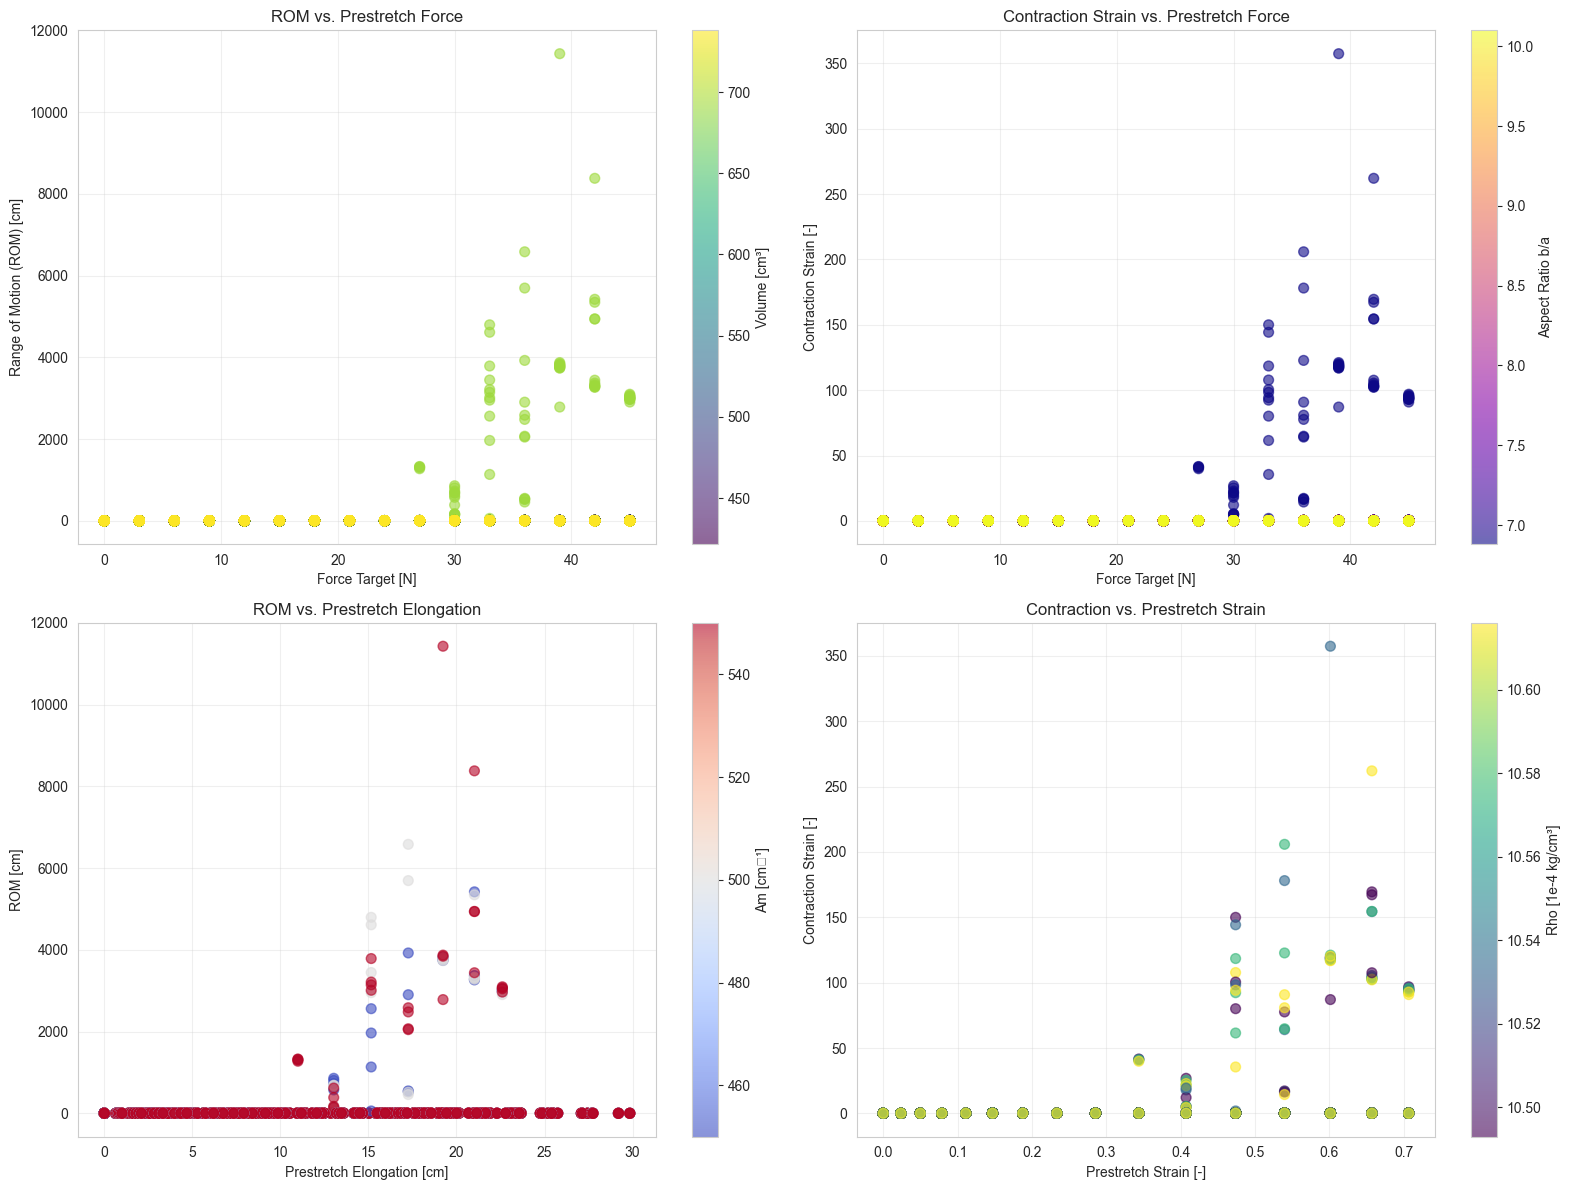

In [13]:
# ROM Analyse
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 3.1: ROM vs Force
ax = axes[0, 0]
scatter = ax.scatter(df['Force_Target_N'], df['ROM_cm'], 
                     c=df['Volume_cm3'], s=50, alpha=0.6, cmap='viridis')
ax.set_xlabel('Force Target [N]')
ax.set_ylabel('Range of Motion (ROM) [cm]')
ax.set_title('ROM vs. Prestretch Force')
ax.grid(True, alpha=0.3)
plt.colorbar(scatter, ax=ax, label='Volume [cm³]')

# 3.2: Contraction Strain vs Force
ax = axes[0, 1]
scatter = ax.scatter(df['Force_Target_N'], df['Contraction_Strain'], 
                     c=df['Aspect_Ratio_b_a'], s=50, alpha=0.6, cmap='plasma')
ax.set_xlabel('Force Target [N]')
ax.set_ylabel('Contraction Strain [-]')
ax.set_title('Contraction Strain vs. Prestretch Force')
ax.grid(True, alpha=0.3)
plt.colorbar(scatter, ax=ax, label='Aspect Ratio b/a')

# 3.3: ROM vs Prestretch Elongation
ax = axes[1, 0]
scatter = ax.scatter(df['Prestretch_Elongation_cm'], df['ROM_cm'], 
                     c=df['Am'], s=50, alpha=0.6, cmap='coolwarm')
ax.set_xlabel('Prestretch Elongation [cm]')
ax.set_ylabel('ROM [cm]')
ax.set_title('ROM vs. Prestretch Elongation')
ax.grid(True, alpha=0.3)
plt.colorbar(scatter, ax=ax, label='Am [cm⁻¹]')

# 3.4: Contraction Strain vs Prestretch Strain
ax = axes[1, 1]
scatter = ax.scatter(df['Prestretch_Strain'], df['Contraction_Strain'], 
                     c=df['Rho'], s=50, alpha=0.6, cmap='viridis')
ax.set_xlabel('Prestretch Strain [-]')
ax.set_ylabel('Contraction Strain [-]')
ax.set_title('Contraction vs. Prestretch Strain')
ax.grid(True, alpha=0.3)
plt.colorbar(scatter, ax=ax, label='Rho [1e-4 kg/cm³]')

plt.tight_layout()
plt.savefig(data_dir / 'contraction_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

## 4. Parameter-Einfluss (einzelne Parameter)

### 4.1 Einfluss von Volume

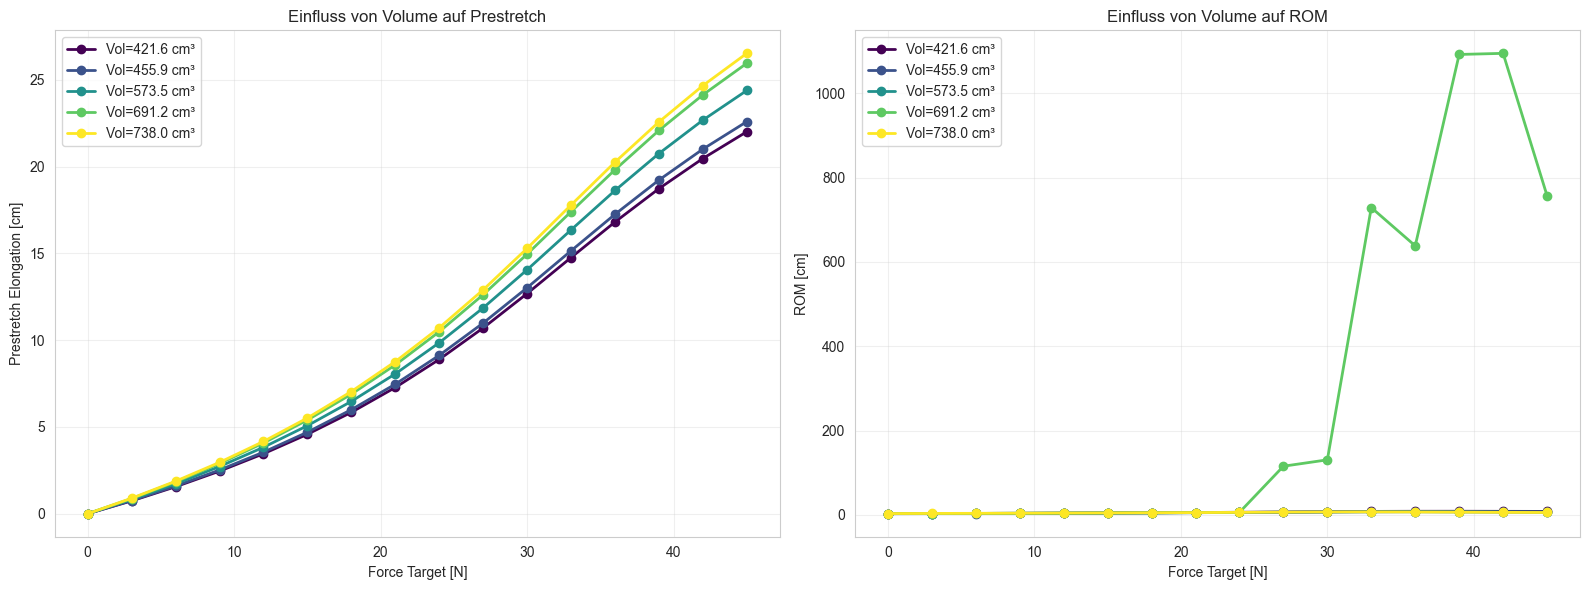

In [14]:
# Volume Einfluss
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

volumes = sorted(df['Volume_cm3'].unique())
colors = plt.cm.viridis(np.linspace(0, 1, len(volumes)))

# Prestretch
ax = axes[0]
for vol, color in zip(volumes, colors):
    subset = df[df['Volume_cm3'] == vol]
    subset_grouped = subset.groupby('Force_Target_N')[['Prestretch_Elongation_cm']].mean()
    ax.plot(subset_grouped.index, subset_grouped['Prestretch_Elongation_cm'], 
            'o-', label=f'Vol={vol} cm³', color=color, linewidth=2, markersize=6)
ax.set_xlabel('Force Target [N]')
ax.set_ylabel('Prestretch Elongation [cm]')
ax.set_title('Einfluss von Volume auf Prestretch')
ax.legend()
ax.grid(True, alpha=0.3)

# ROM
ax = axes[1]
for vol, color in zip(volumes, colors):
    subset = df[df['Volume_cm3'] == vol]
    subset_grouped = subset.groupby('Force_Target_N')[['ROM_cm']].mean()
    ax.plot(subset_grouped.index, subset_grouped['ROM_cm'], 
            'o-', label=f'Vol={vol} cm³', color=color, linewidth=2, markersize=6)
ax.set_xlabel('Force Target [N]')
ax.set_ylabel('ROM [cm]')
ax.set_title('Einfluss von Volume auf ROM')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(data_dir / 'volume_influence.png', dpi=300, bbox_inches='tight')
plt.show()

### 4.2 Einfluss von Aspect Ratio

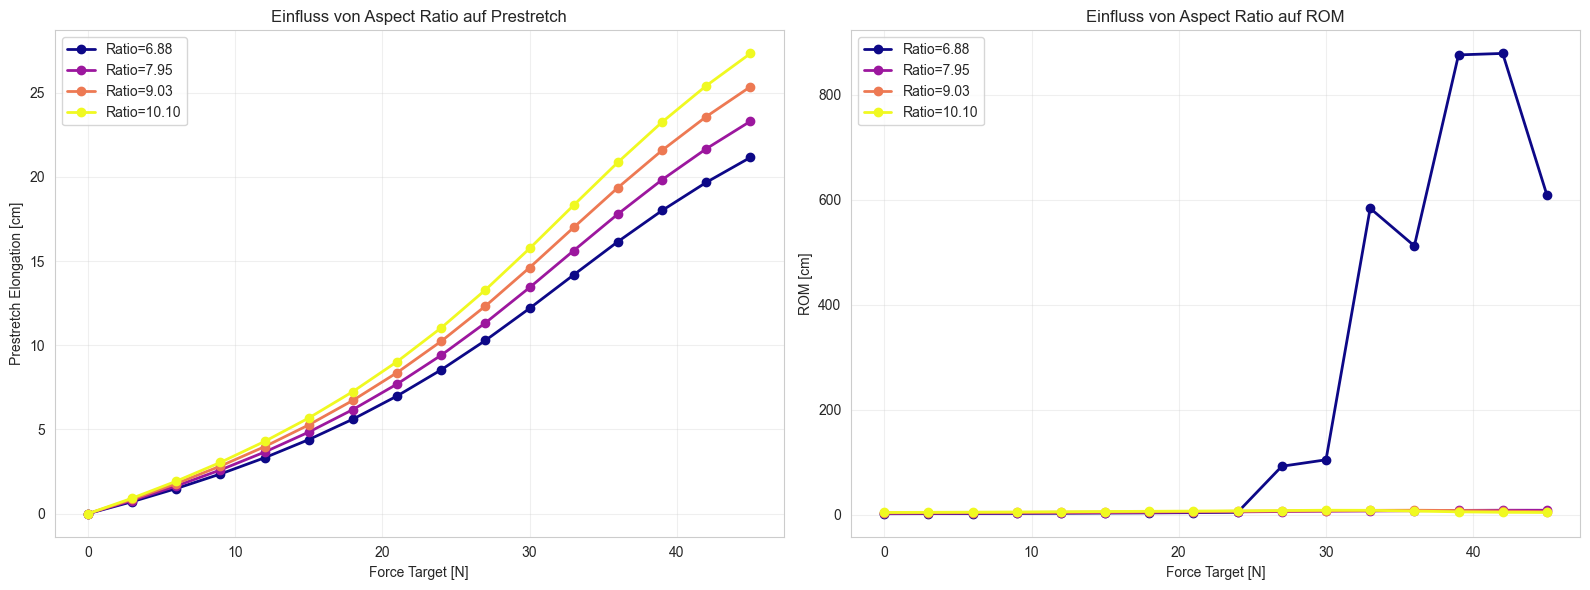

In [15]:
# Aspect Ratio Einfluss
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ratios = sorted(df['Aspect_Ratio_b_a'].unique())
colors = plt.cm.plasma(np.linspace(0, 1, len(ratios)))

# Prestretch
ax = axes[0]
for ratio, color in zip(ratios, colors):
    subset = df[df['Aspect_Ratio_b_a'] == ratio]
    subset_grouped = subset.groupby('Force_Target_N')[['Prestretch_Elongation_cm']].mean()
    ax.plot(subset_grouped.index, subset_grouped['Prestretch_Elongation_cm'], 
            'o-', label=f'Ratio={ratio:.2f}', color=color, linewidth=2, markersize=6)
ax.set_xlabel('Force Target [N]')
ax.set_ylabel('Prestretch Elongation [cm]')
ax.set_title('Einfluss von Aspect Ratio auf Prestretch')
ax.legend()
ax.grid(True, alpha=0.3)

# ROM
ax = axes[1]
for ratio, color in zip(ratios, colors):
    subset = df[df['Aspect_Ratio_b_a'] == ratio]
    subset_grouped = subset.groupby('Force_Target_N')[['ROM_cm']].mean()
    ax.plot(subset_grouped.index, subset_grouped['ROM_cm'], 
            'o-', label=f'Ratio={ratio:.2f}', color=color, linewidth=2, markersize=6)
ax.set_xlabel('Force Target [N]')
ax.set_ylabel('ROM [cm]')
ax.set_title('Einfluss von Aspect Ratio auf ROM')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(data_dir / 'aspect_ratio_influence.png', dpi=300, bbox_inches='tight')
plt.show()

### 4.3 Einfluss von Am und Rho

/var/folders/qg/82ll9gvd1pd4329hnkdpf8ch0000gn/T/ipykernel_67259/2326641431.py:60: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/qg/82ll9gvd1pd4329hnkdpf8ch0000gn/T/ipykernel_67259/2326641431.py:61: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  plt.savefig(data_dir / 'am_rho_influence.png', dpi=300, bbox_inches='tight')
/Users/canis/Library/Python/3.11/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


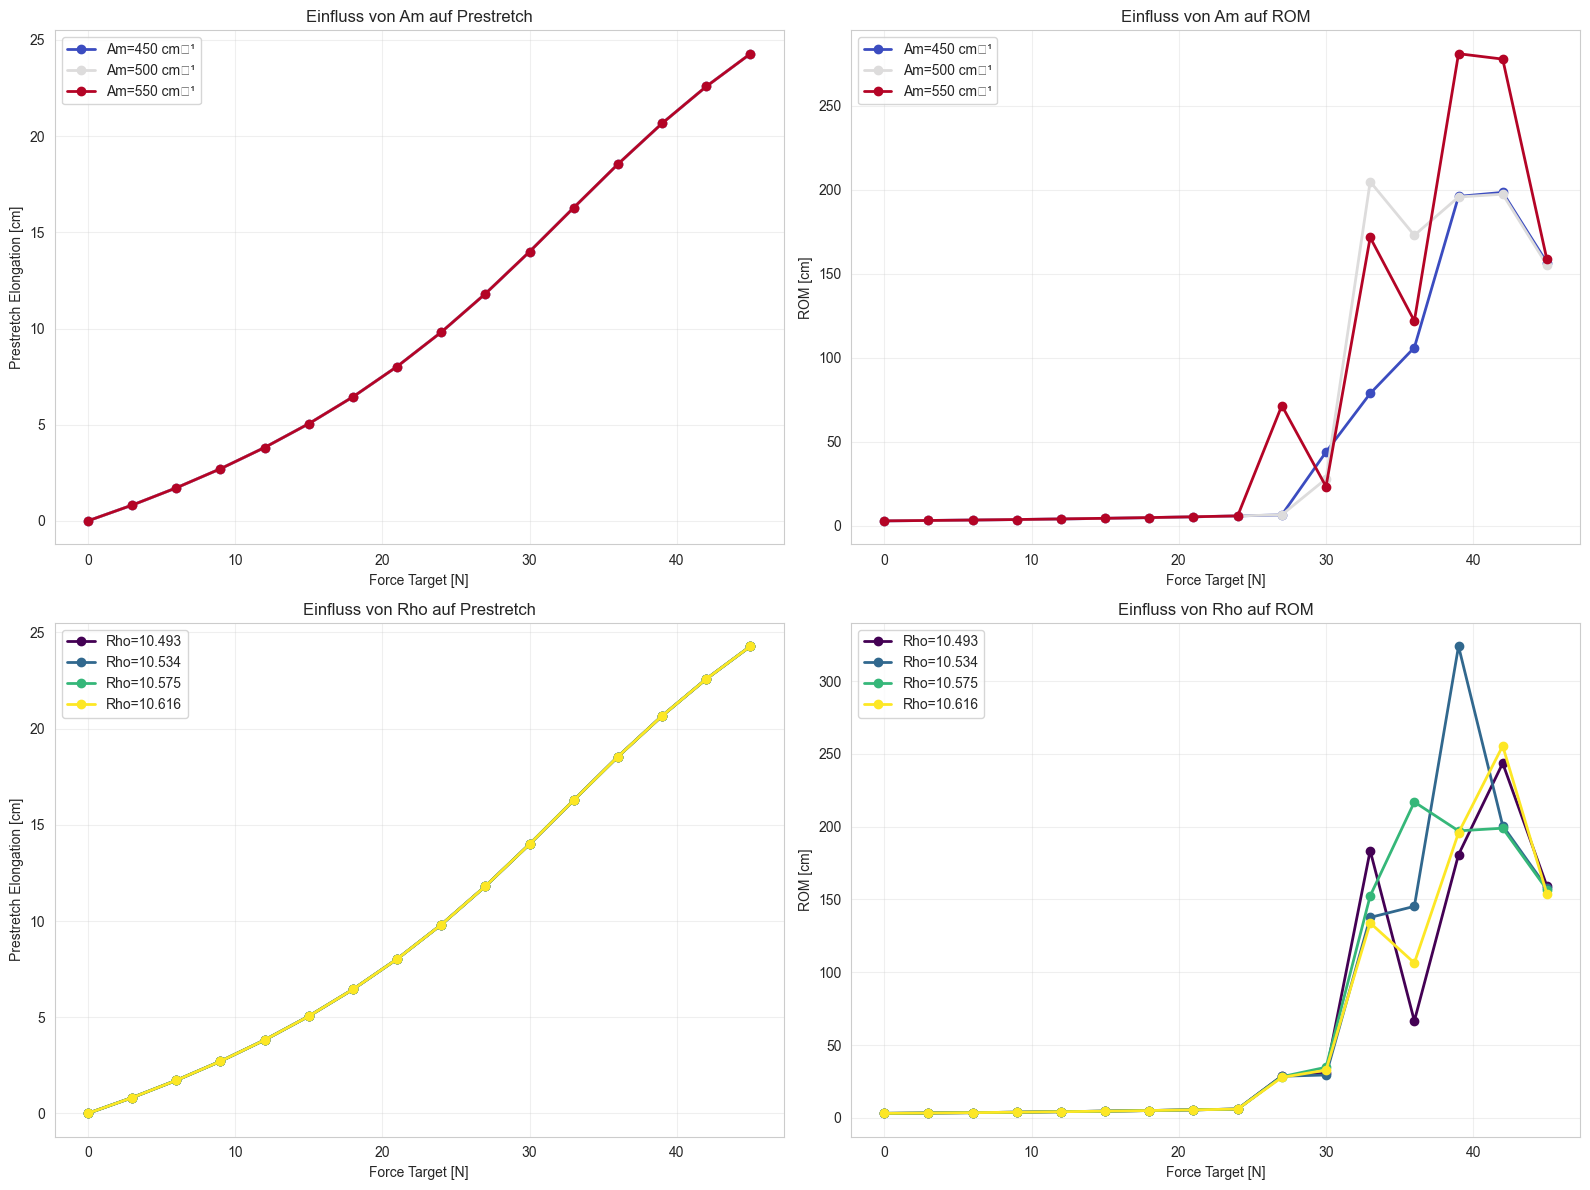

In [16]:
# Am und Rho Einfluss
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Am Einfluss auf Prestretch
ax = axes[0, 0]
am_values = sorted(df['Am'].unique())
colors = plt.cm.coolwarm(np.linspace(0, 1, len(am_values)))
for am, color in zip(am_values, colors):
    subset = df[df['Am'] == am]
    subset_grouped = subset.groupby('Force_Target_N')[['Prestretch_Elongation_cm']].mean()
    ax.plot(subset_grouped.index, subset_grouped['Prestretch_Elongation_cm'], 
            'o-', label=f'Am={am} cm⁻¹', color=color, linewidth=2, markersize=6)
ax.set_xlabel('Force Target [N]')
ax.set_ylabel('Prestretch Elongation [cm]')
ax.set_title('Einfluss von Am auf Prestretch')
ax.legend()
ax.grid(True, alpha=0.3)

# Am Einfluss auf ROM
ax = axes[0, 1]
for am, color in zip(am_values, colors):
    subset = df[df['Am'] == am]
    subset_grouped = subset.groupby('Force_Target_N')[['ROM_cm']].mean()
    ax.plot(subset_grouped.index, subset_grouped['ROM_cm'], 
            'o-', label=f'Am={am} cm⁻¹', color=color, linewidth=2, markersize=6)
ax.set_xlabel('Force Target [N]')
ax.set_ylabel('ROM [cm]')
ax.set_title('Einfluss von Am auf ROM')
ax.legend()
ax.grid(True, alpha=0.3)

# Rho Einfluss auf Prestretch
ax = axes[1, 0]
rho_values = sorted(df['Rho'].unique())
colors = plt.cm.viridis(np.linspace(0, 1, len(rho_values)))
for rho, color in zip(rho_values, colors):
    subset = df[df['Rho'] == rho]
    subset_grouped = subset.groupby('Force_Target_N')[['Prestretch_Elongation_cm']].mean()
    ax.plot(subset_grouped.index, subset_grouped['Prestretch_Elongation_cm'], 
            'o-', label=f'Rho={rho}', color=color, linewidth=2, markersize=6)
ax.set_xlabel('Force Target [N]')
ax.set_ylabel('Prestretch Elongation [cm]')
ax.set_title('Einfluss von Rho auf Prestretch')
ax.legend()
ax.grid(True, alpha=0.3)

# Rho Einfluss auf ROM
ax = axes[1, 1]
for rho, color in zip(rho_values, colors):
    subset = df[df['Rho'] == rho]
    subset_grouped = subset.groupby('Force_Target_N')[['ROM_cm']].mean()
    ax.plot(subset_grouped.index, subset_grouped['ROM_cm'], 
            'o-', label=f'Rho={rho}', color=color, linewidth=2, markersize=6)
ax.set_xlabel('Force Target [N]')
ax.set_ylabel('ROM [cm]')
ax.set_title('Einfluss von Rho auf ROM')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(data_dir / 'am_rho_influence.png', dpi=300, bbox_inches='tight')
plt.show()

## 5. Heatmaps für Parameterkombinationen

### 5.1 ROM Heatmap: Force vs Volume

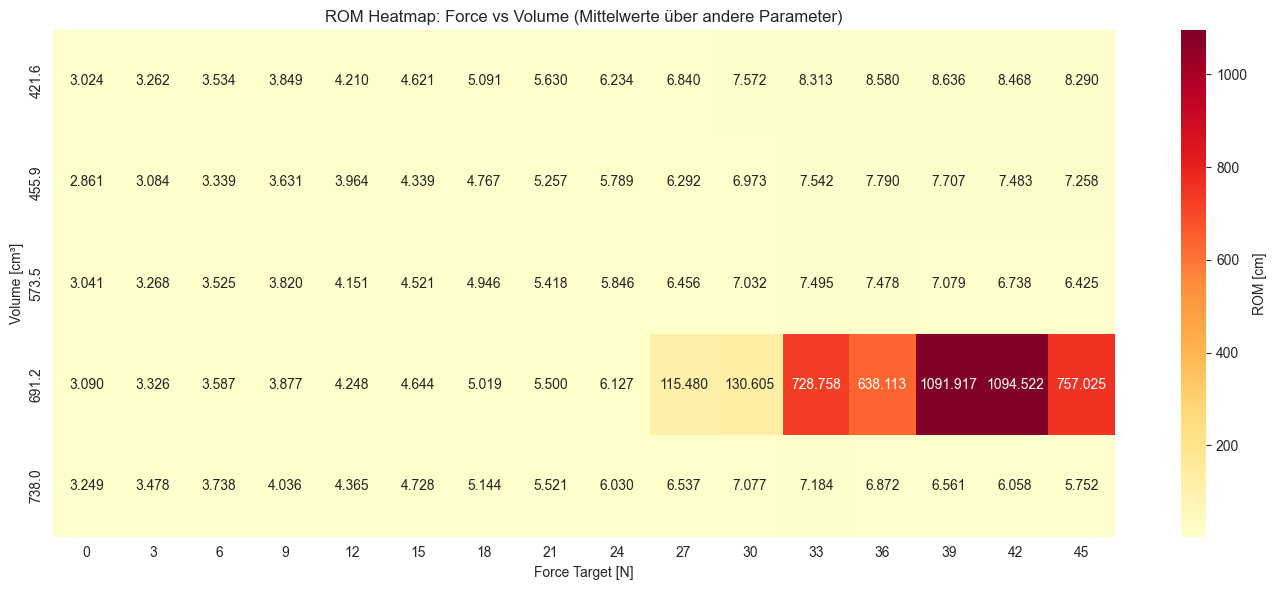

In [17]:
# Heatmap: ROM als Funktion von Force und Volume
pivot_rom = df.groupby(['Force_Target_N', 'Volume_cm3'])['ROM_cm'].mean().reset_index()
pivot_rom = pivot_rom.pivot(index='Volume_cm3', columns='Force_Target_N', values='ROM_cm')

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(pivot_rom, annot=True, fmt='.3f', cmap='YlOrRd', ax=ax, 
            cbar_kws={'label': 'ROM [cm]'})
ax.set_xlabel('Force Target [N]')
ax.set_ylabel('Volume [cm³]')
ax.set_title('ROM Heatmap: Force vs Volume (Mittelwerte über andere Parameter)')
plt.tight_layout()
plt.savefig(data_dir / 'heatmap_rom_force_volume.png', dpi=300, bbox_inches='tight')
plt.show()

### 5.2 Prestretch Strain Heatmap: Force vs Aspect Ratio

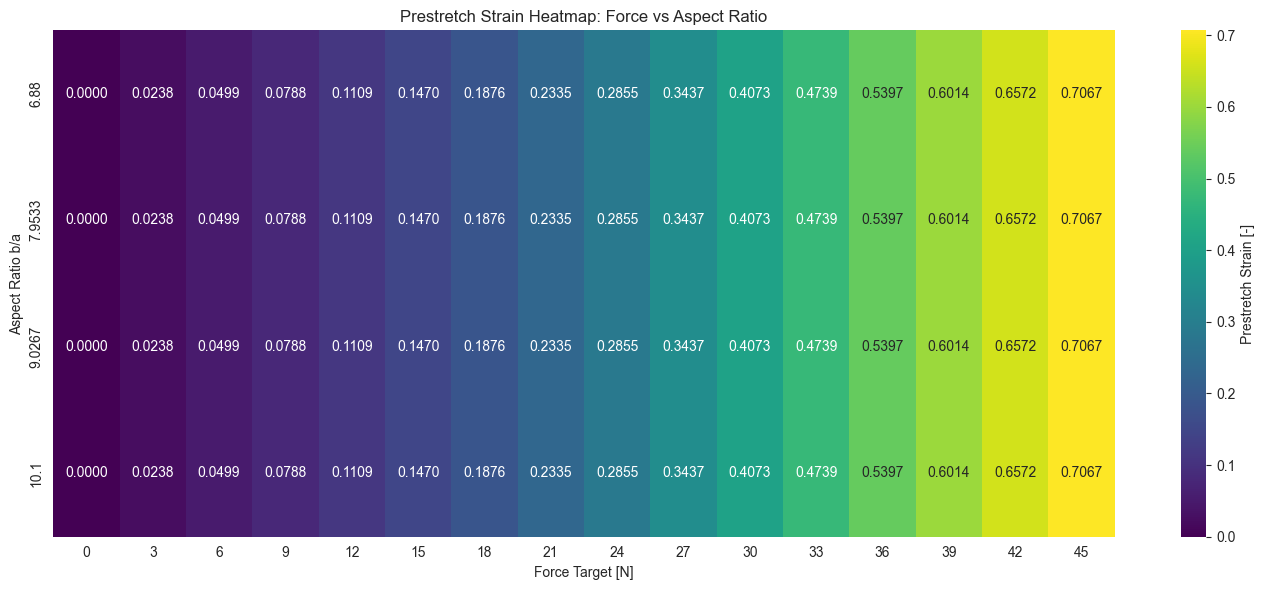

In [18]:
# Heatmap: Prestretch Strain als Funktion von Force und Aspect Ratio
pivot_strain = df.groupby(['Force_Target_N', 'Aspect_Ratio_b_a'])['Prestretch_Strain'].mean().reset_index()
pivot_strain = pivot_strain.pivot(index='Aspect_Ratio_b_a', columns='Force_Target_N', values='Prestretch_Strain')

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(pivot_strain, annot=True, fmt='.4f', cmap='viridis', ax=ax, 
            cbar_kws={'label': 'Prestretch Strain [-]'})
ax.set_xlabel('Force Target [N]')
ax.set_ylabel('Aspect Ratio b/a')
ax.set_title('Prestretch Strain Heatmap: Force vs Aspect Ratio')
plt.tight_layout()
plt.savefig(data_dir / 'heatmap_prestretch_force_ratio.png', dpi=300, bbox_inches='tight')
plt.show()

### 5.3 Contraction Strain Heatmap: Am vs Rho

/var/folders/qg/82ll9gvd1pd4329hnkdpf8ch0000gn/T/ipykernel_67259/472987715.py:11: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/qg/82ll9gvd1pd4329hnkdpf8ch0000gn/T/ipykernel_67259/472987715.py:12: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  plt.savefig(data_dir / 'heatmap_contraction_am_rho.png', dpi=300, bbox_inches='tight')
/Users/canis/Library/Python/3.11/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


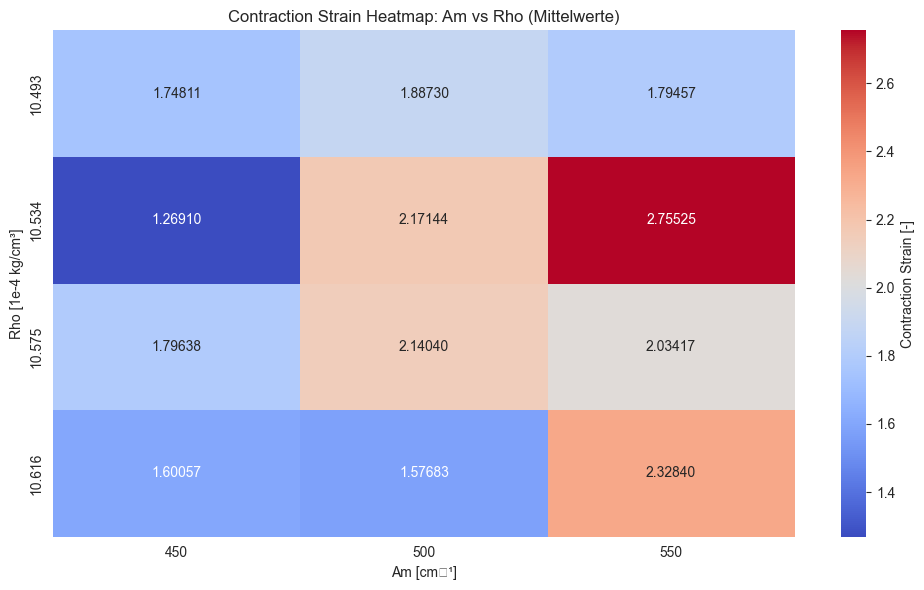

In [19]:
# Heatmap: Contraction Strain als Funktion von Am und Rho
pivot_contraction = df.groupby(['Am', 'Rho'])['Contraction_Strain'].mean().reset_index()
pivot_contraction = pivot_contraction.pivot(index='Rho', columns='Am', values='Contraction_Strain')

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(pivot_contraction, annot=True, fmt='.5f', cmap='coolwarm', ax=ax, 
            cbar_kws={'label': 'Contraction Strain [-]'})
ax.set_xlabel('Am [cm⁻¹]')
ax.set_ylabel('Rho [1e-4 kg/cm³]')
ax.set_title('Contraction Strain Heatmap: Am vs Rho (Mittelwerte)')
plt.tight_layout()
plt.savefig(data_dir / 'heatmap_contraction_am_rho.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. Korrelationsanalyse

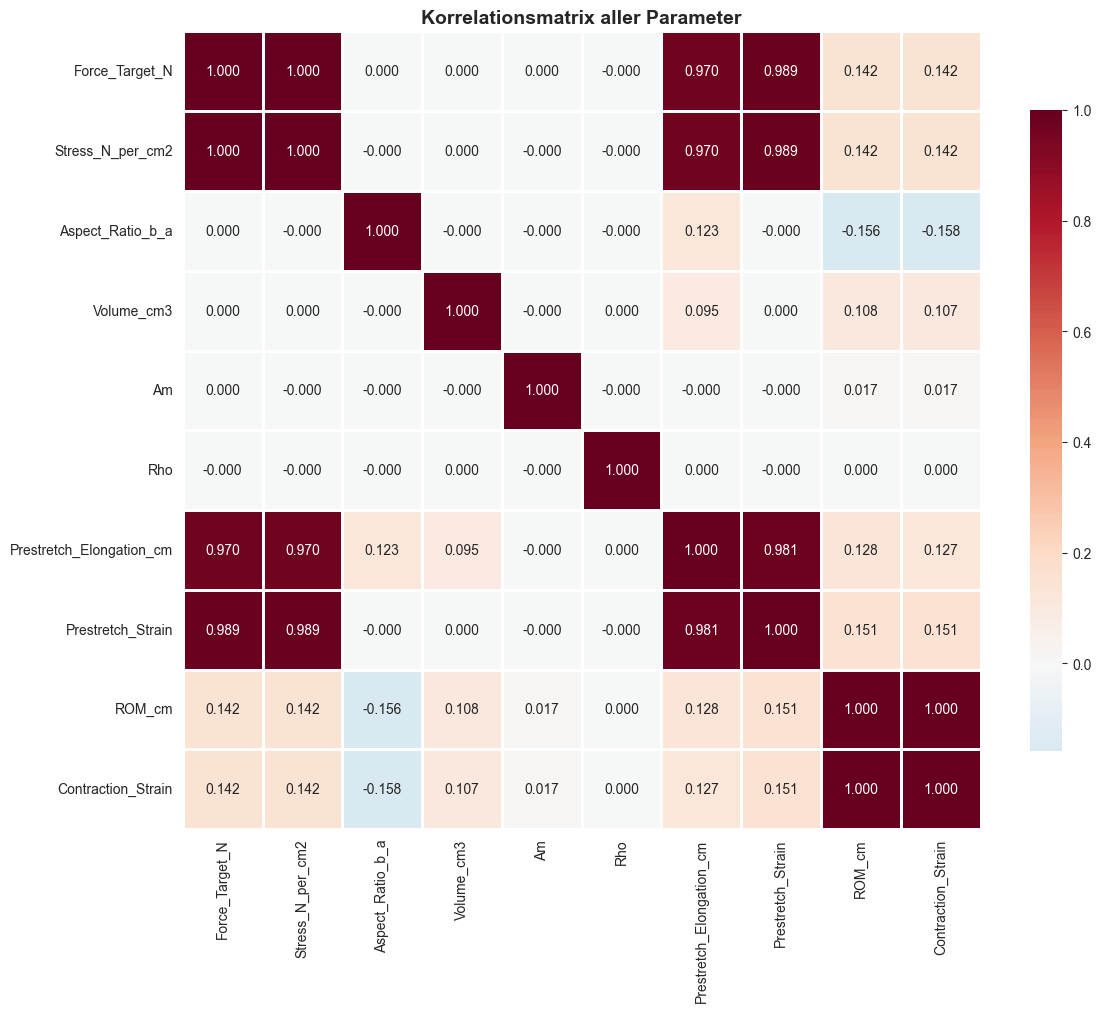


Stärkste Korrelationen mit ROM:
ROM_cm                      1.000000
Contraction_Strain          0.999999
Prestretch_Strain           0.151187
Stress_N_per_cm2            0.141603
Force_Target_N              0.141603
Prestretch_Elongation_cm    0.127548
Volume_cm3                  0.108076
Am                          0.016990
Rho                         0.000004
Aspect_Ratio_b_a           -0.156472
Name: ROM_cm, dtype: float64

Stärkste Korrelationen mit Contraction Strain:
Contraction_Strain          1.000000
ROM_cm                      0.999999
Prestretch_Strain           0.151185
Stress_N_per_cm2            0.141582
Force_Target_N              0.141582
Prestretch_Elongation_cm    0.127316
Volume_cm3                  0.107283
Am                          0.016990
Rho                         0.000006
Aspect_Ratio_b_a           -0.157537
Name: Contraction_Strain, dtype: float64


In [20]:
# Korrelationsmatrix
correlation_cols = ['Force_Target_N', 'Stress_N_per_cm2', 'Aspect_Ratio_b_a', 
                    'Volume_cm3', 'Am', 'Rho',
                    'Prestretch_Elongation_cm', 'Prestretch_Strain',
                    'ROM_cm', 'Contraction_Strain']

correlation_matrix = df[correlation_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title('Korrelationsmatrix aller Parameter', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(data_dir / 'correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# Zeige stärkste Korrelationen
print("\nStärkste Korrelationen mit ROM:")
rom_corr = correlation_matrix['ROM_cm'].sort_values(ascending=False)
print(rom_corr)

print("\nStärkste Korrelationen mit Contraction Strain:")
strain_corr = correlation_matrix['Contraction_Strain'].sort_values(ascending=False)
print(strain_corr)

## 7. Statistische Zusammenfassung

In [21]:
# Gruppierung nach Force für statistische Analyse
force_stats = df.groupby('Force_Target_N').agg({
    'Prestretch_Elongation_cm': ['mean', 'std', 'min', 'max'],
    'Prestretch_Strain': ['mean', 'std', 'min', 'max'],
    'ROM_cm': ['mean', 'std', 'min', 'max'],
    'Contraction_Strain': ['mean', 'std', 'min', 'max']
}).round(6)

print("\nStatistik nach Force Target:")
print("="*100)
print(force_stats)

# Speichern
force_stats.to_csv(data_dir / 'statistics_by_force.csv')
print(f"\nStatistik gespeichert in: {data_dir / 'statistics_by_force.csv'}")


Statistik nach Force Target:
               Prestretch_Elongation_cm                                  \
                                   mean       std        min        max   
Force_Target_N                                                            
0                              0.000000  0.000000   0.000000   0.000000   
3                              0.816972  0.098204   0.644808   1.003777   
6                              1.714877  0.206136   1.353493   2.106994   
9                              2.707759  0.325484   2.137140   3.326903   
12                             3.812789  0.458314   3.009301   4.684607   
15                             5.050743  0.607121   3.986376   6.205626   
18                             6.445984  0.774835   5.087591   7.919897   
21                             8.024957  0.964634   6.333820   9.859911   
24                             9.810992  1.179323   7.743475  12.054332   
27                            11.811841  1.419834   9.322676  14.51268

## 8. Vergleich: Force=0 vs Force>0

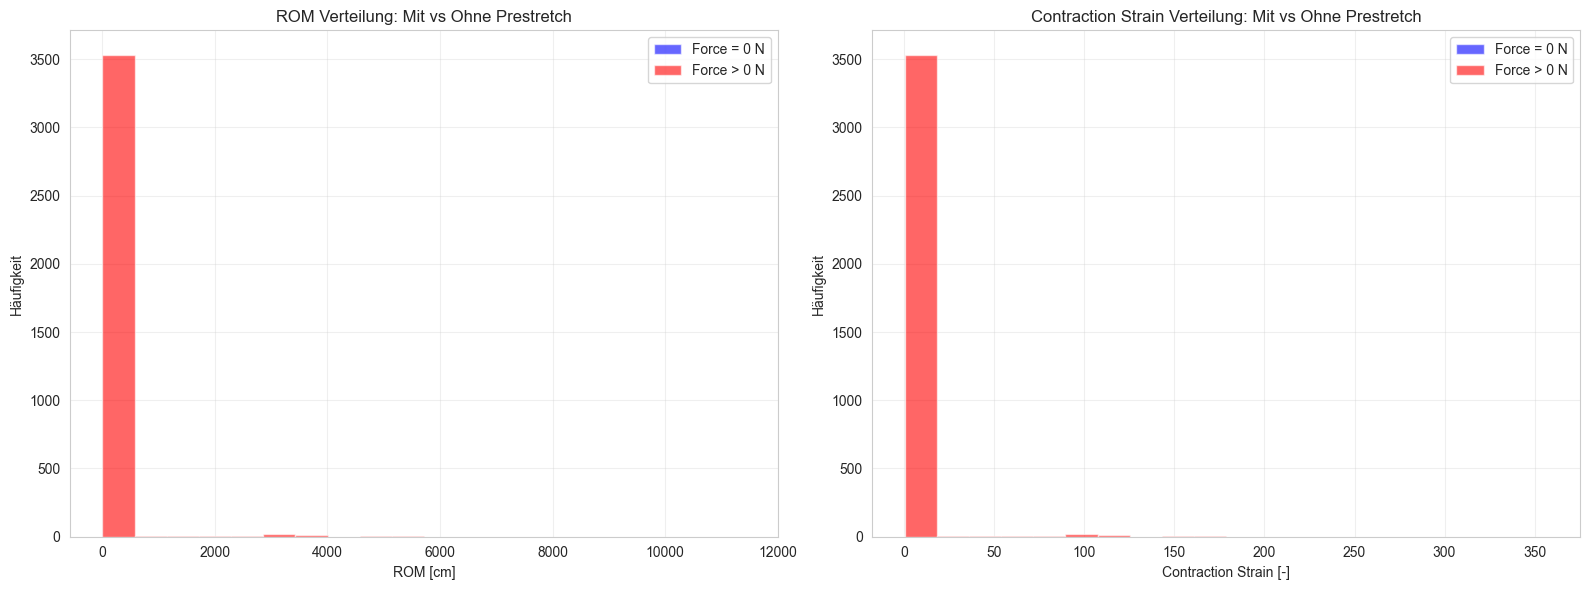


Vergleich mit/ohne Prestretch:

Ohne Prestretch (Force=0):
  ROM Mittelwert: 3.0528 ± 0.9188 cm
  Contraction Strain: 0.087444 ± 0.018987

Mit Prestretch (Force>0):
  ROM Mittelwert: 65.8450 ± 495.5140 cm
  Contraction Strain: 2.047726 ± 15.494112

Differenz:
  ROM: 62.7922 cm
  Contraction Strain: 1.960282


In [22]:
# Vergleich mit und ohne Prestretch
df_no_force = df[df['Force_Target_N'] == 0]
df_with_force = df[df['Force_Target_N'] > 0]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ROM Verteilung
ax = axes[0]
ax.hist(df_no_force['ROM_cm'], bins=20, alpha=0.6, label='Force = 0 N', color='blue')
ax.hist(df_with_force['ROM_cm'], bins=20, alpha=0.6, label='Force > 0 N', color='red')
ax.set_xlabel('ROM [cm]')
ax.set_ylabel('Häufigkeit')
ax.set_title('ROM Verteilung: Mit vs Ohne Prestretch')
ax.legend()
ax.grid(True, alpha=0.3)

# Contraction Strain Verteilung
ax = axes[1]
ax.hist(df_no_force['Contraction_Strain'], bins=20, alpha=0.6, label='Force = 0 N', color='blue')
ax.hist(df_with_force['Contraction_Strain'], bins=20, alpha=0.6, label='Force > 0 N', color='red')
ax.set_xlabel('Contraction Strain [-]')
ax.set_ylabel('Häufigkeit')
ax.set_title('Contraction Strain Verteilung: Mit vs Ohne Prestretch')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(data_dir / 'comparison_with_without_prestretch.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nVergleich mit/ohne Prestretch:")
print("="*80)
print(f"\nOhne Prestretch (Force=0):")
print(f"  ROM Mittelwert: {df_no_force['ROM_cm'].mean():.4f} ± {df_no_force['ROM_cm'].std():.4f} cm")
print(f"  Contraction Strain: {df_no_force['Contraction_Strain'].mean():.6f} ± {df_no_force['Contraction_Strain'].std():.6f}")

print(f"\nMit Prestretch (Force>0):")
print(f"  ROM Mittelwert: {df_with_force['ROM_cm'].mean():.4f} ± {df_with_force['ROM_cm'].std():.4f} cm")
print(f"  Contraction Strain: {df_with_force['Contraction_Strain'].mean():.6f} ± {df_with_force['Contraction_Strain'].std():.6f}")

print(f"\nDifferenz:")
print(f"  ROM: {df_with_force['ROM_cm'].mean() - df_no_force['ROM_cm'].mean():.4f} cm")
print(f"  Contraction Strain: {df_with_force['Contraction_Strain'].mean() - df_no_force['Contraction_Strain'].mean():.6f}")

## 9. 3D Visualisierung (optional)

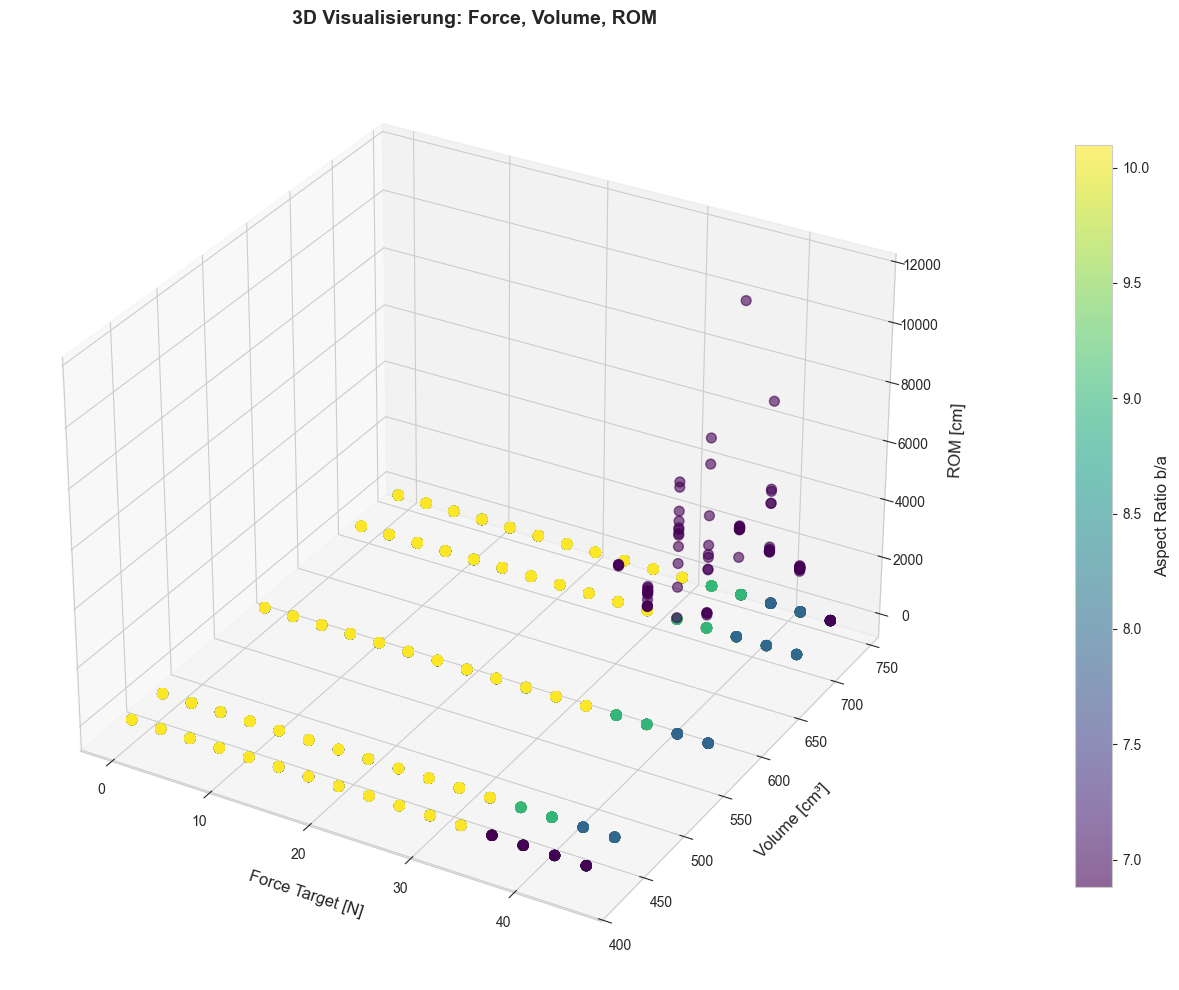

In [23]:
from mpl_toolkits.mplot3d import Axes3D

# 3D Plot: Force, Volume, ROM
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(df['Force_Target_N'], df['Volume_cm3'], df['ROM_cm'],
                     c=df['Aspect_Ratio_b_a'], s=50, alpha=0.6, cmap='viridis')

ax.set_xlabel('Force Target [N]', fontsize=12, labelpad=10)
ax.set_ylabel('Volume [cm³]', fontsize=12, labelpad=10)
ax.set_zlabel('ROM [cm]', fontsize=12, labelpad=10)
ax.set_title('3D Visualisierung: Force, Volume, ROM', fontsize=14, fontweight='bold', pad=20)

cbar = plt.colorbar(scatter, ax=ax, pad=0.1, shrink=0.8)
cbar.set_label('Aspect Ratio b/a', fontsize=12)

plt.tight_layout()
plt.savefig(data_dir / '3d_force_volume_rom.png', dpi=300, bbox_inches='tight')
plt.show()

## 10. Zusammenfassung

Alle Plots wurden gespeichert in: `parameter_sweep_DA_20260227_153207/`

### Wichtige Erkenntnisse:

1. **Prestretch**: Die Prestretch-Elongation steigt erwartungsgemäß mit der Kraft
2. **ROM**: Die Kontraktionsamplitude wird von mehreren Parametern beeinflusst
3. **Parameter-Einflüsse**: Volume, Aspect Ratio, Am und Rho haben unterschiedliche Effekte
4. **Korrelationen**: Siehe Korrelationsmatrix für quantitative Zusammenhänge

⚠️ **Hinweis**: Die Simulationen liefen nur 50ms - das ist möglicherweise zu kurz für einen vollständigen Kontraktionszyklus (siehe ENDTIME_MS in run_parameter_sweep_2702.sh).